# Seasonal Agriculture Performance Data Analytics

## Project Objective

The objective of this project is to analyze agricultural performance across different
seasons, crops, regions, and other relevant factors. The analysis focuses on identifying
patterns in production, yield, area cultivated, and other agricultural indicators.

The project includes:
- Exploratory Data Analysis
- Data cleaning and preprocessing
- Univariate analysis
- Bivariate analysis
- Multivariate analysis
- Correlation analysis
- Seasonal comparison
- Outlier analysis
- Student-designed analyses
- Business/agricultural insights
- Evidence-based recommendations

#1. Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


##2. Load Dataset

In [6]:
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully.")
print("File:", file_name)

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv
Dataset loaded successfully.
File: seasonal_agriculture_performance_dataset.csv


##3. Top 5 Rows

In [7]:
print("Top 5 rows:")
display(df.head())

Top 5 rows:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


##4. Dataset Shape

In [8]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)

Number of rows: 4000
Number of columns: 28
Dataset shape: (4000, 28)


##5. Dataset Structure

In [9]:
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha             

##6. Column Names

In [10]:
print("Columns in the dataset:")

for i, col in enumerate(df.columns, 1):
    print(i, "-", col)

Columns in the dataset:
1 - Farm_ID
2 - State
3 - District
4 - Crop
5 - Season
6 - Farm_Area_Hectares
7 - Rainfall_mm
8 - Avg_Temperature_C
9 - Humidity_pct
10 - Sunlight_Hours_Day
11 - Soil_pH
12 - Soil_Moisture_pct
13 - Nitrogen_kg_ha
14 - Phosphorus_kg_ha
15 - Potassium_kg_ha
16 - Irrigation_Method
17 - Fertilizer_kg_ha
18 - Pesticide_Litre_ha
19 - Seed_Quality_Score
20 - Yield_Tonnes_Ha
21 - Production_Tonnes
22 - Market_Price_INR_Tonne
23 - Total_Cost_INR
24 - Revenue_INR
25 - Profit_INR
26 - Water_Used_m3
27 - Water_Efficiency_t_per_1000m3
28 - Disease_Pest_Risk_pct


##7. Data Types

In [11]:
print("Data types:")
display(df.dtypes)

Data types:


,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [12]:
#Check numeric and categorical columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numeric columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


##8. Missing Values

In [13]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing Values": missing.values,
    "Missing %": (missing.values / len(df) * 100).round(2)
})

display(missing_df[missing_df["Missing Values"] > 0])

,Column,Missing Values,Missing %
6,Rainfall_mm,48,1.2
11,Soil_Moisture_pct,40,1.0
19,Yield_Tonnes_Ha,32,0.8


Handle Missing Values

In [14]:
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled.")

Missing values handled.


Verify

In [15]:
print("Total missing values after treatment:",
      df.isnull().sum().sum())

Total missing values after treatment: 0


##9. Duplicate Records

In [16]:
duplicates = df.duplicated().sum()

print("Number of duplicate records:", duplicates)

Number of duplicate records: 0


##10. Descriptive Statistics

In [17]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,4000.0,NaN,NaN,NaN,600.922825,287.193381,80.0,371.575,582.0,831.975,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


Numeric statistics

In [18]:
display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.922825,287.193381,80.000,371.575,582.0000,831.97500,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


##**11**. Unique Values

In [19]:
for col in categorical_cols:
    print(f"\n{col}")
    print("Unique values:", df[col].nunique())
    print(df[col].unique()[:20])


Farm_ID
Unique values: 4000
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State
Unique values: 8
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District
Unique values: 10
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop
Unique values: 8
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season
Unique values: 3
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method
Unique values: 4
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


#12. Univariate Analysis
##12.1 Distribution of Numeric Variables

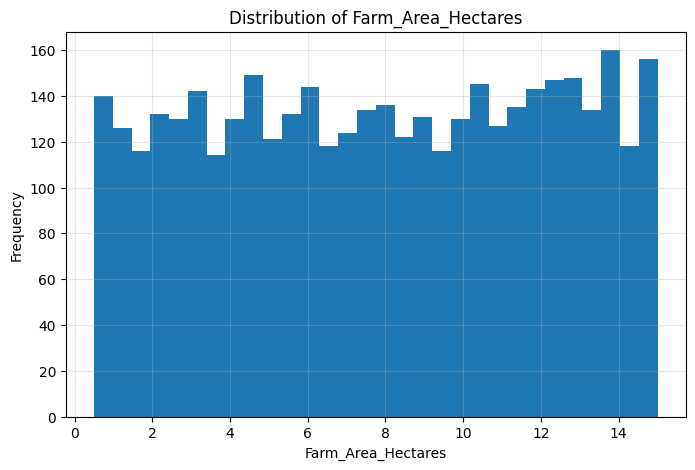

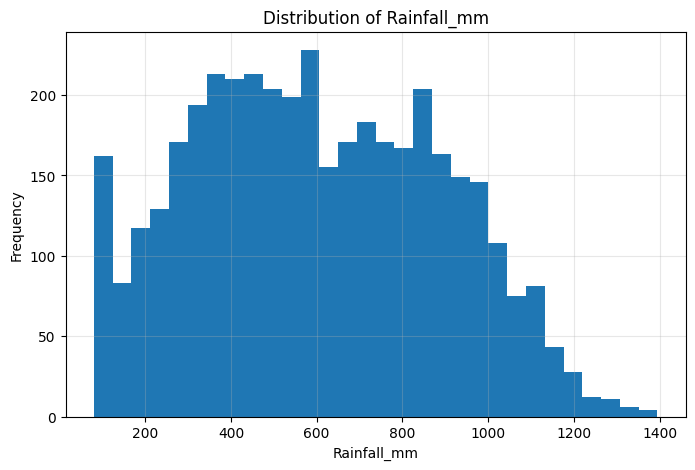

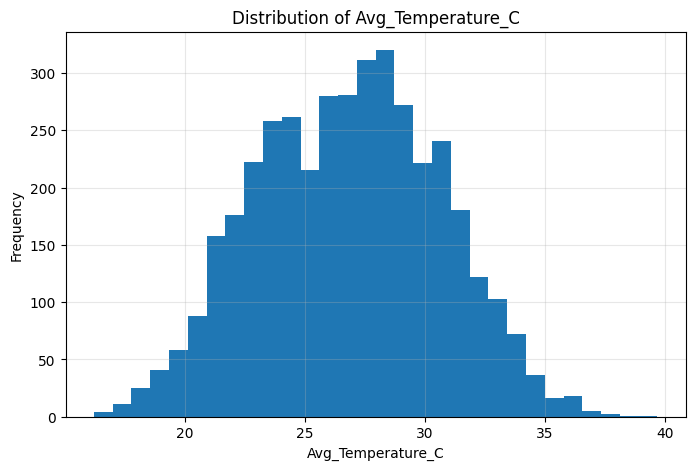

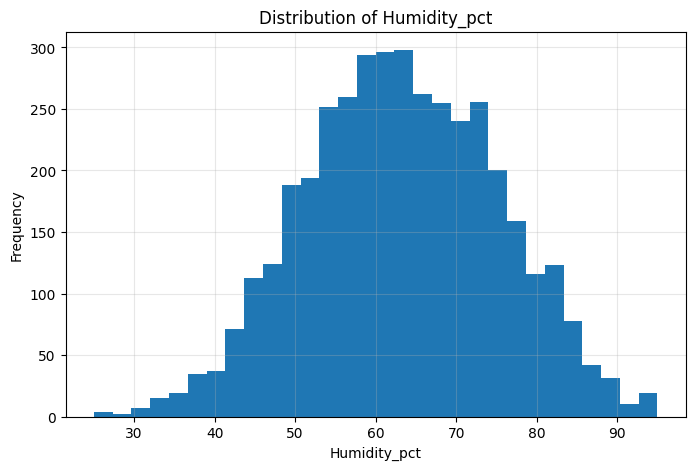

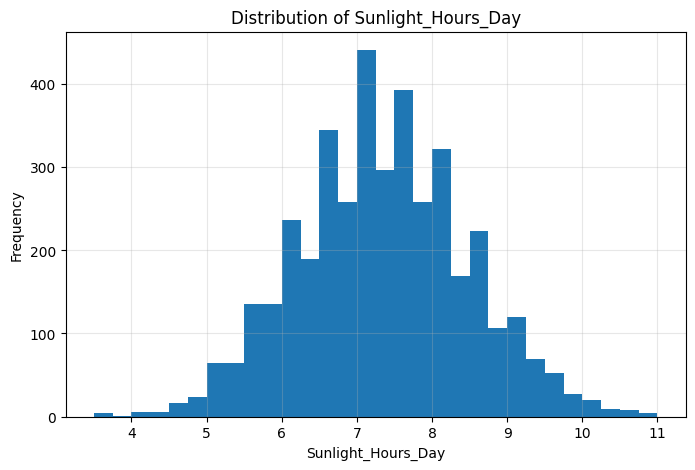

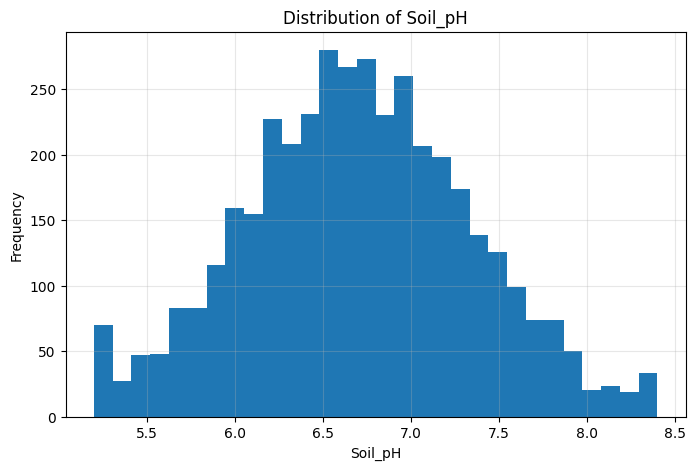

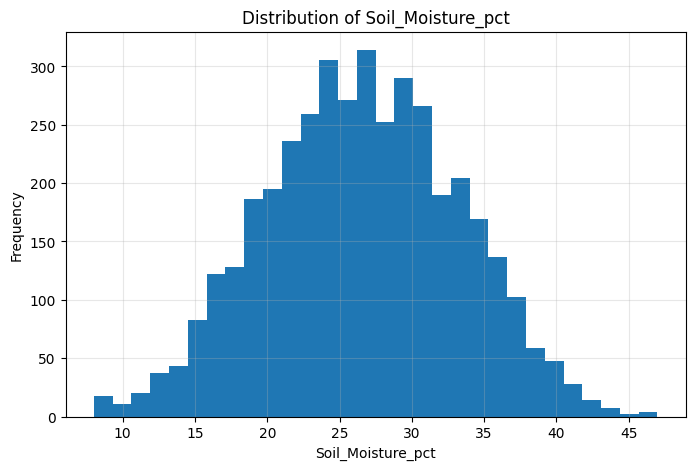

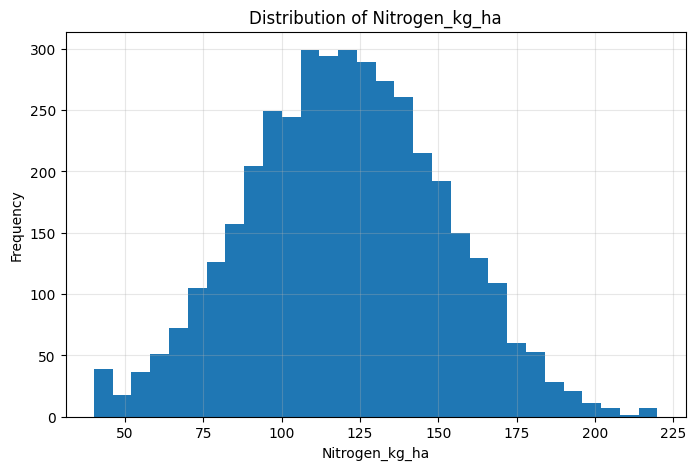

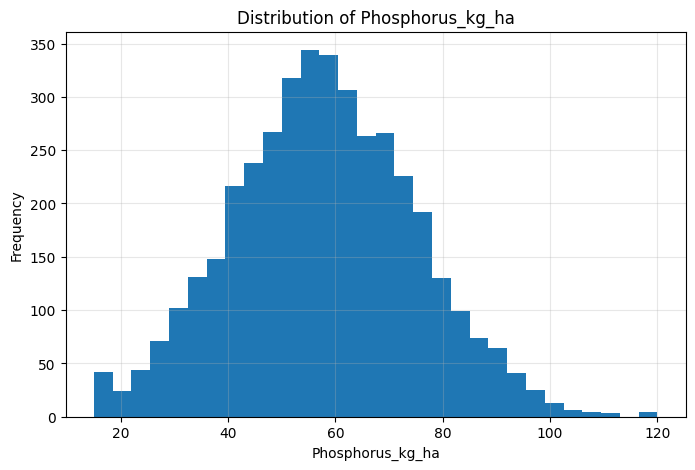

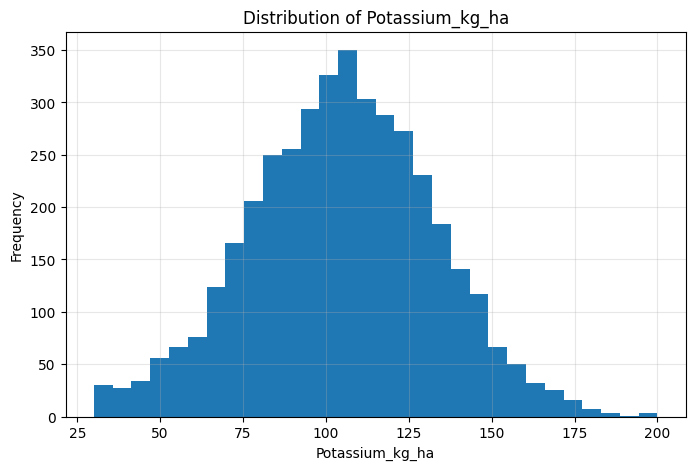

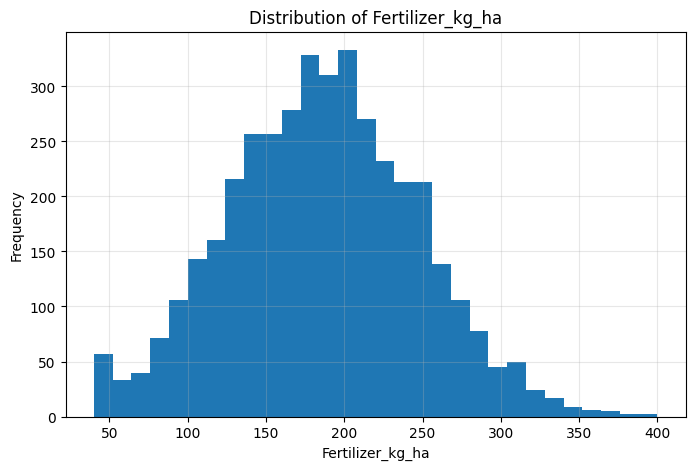

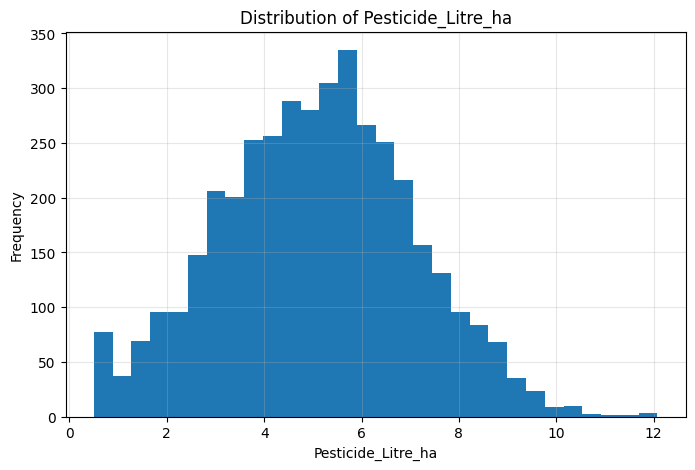

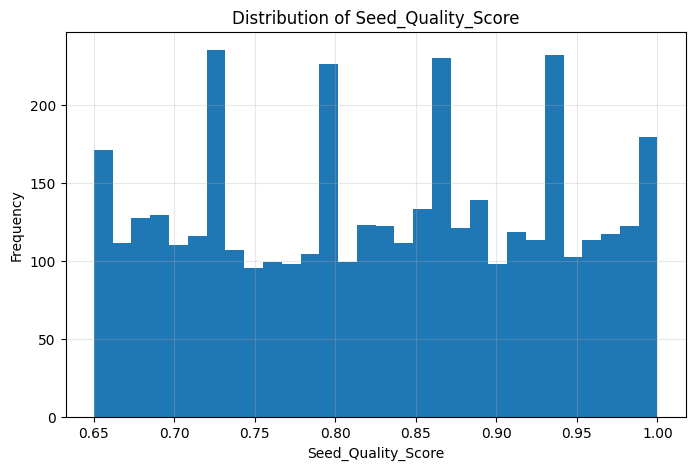

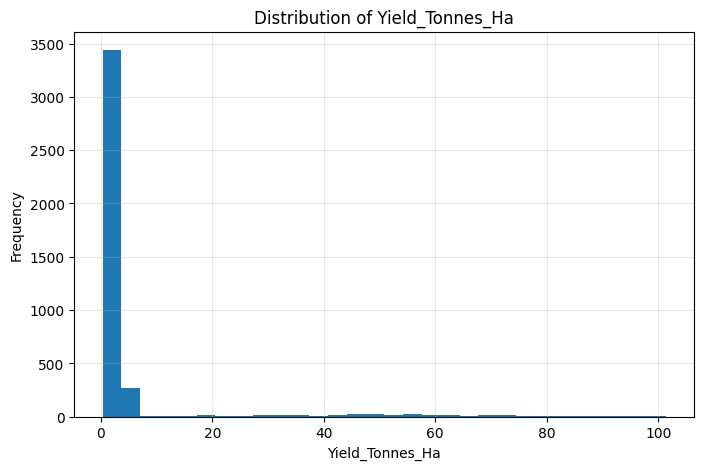

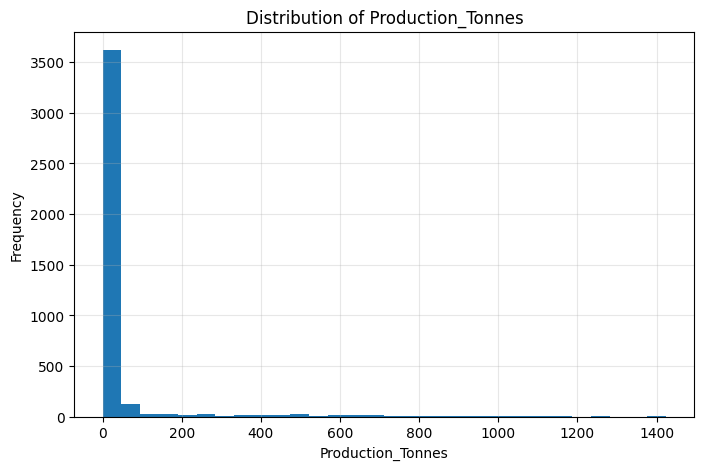

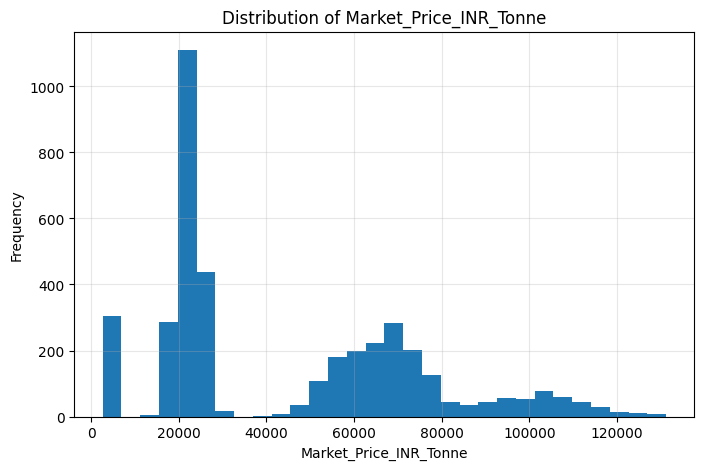

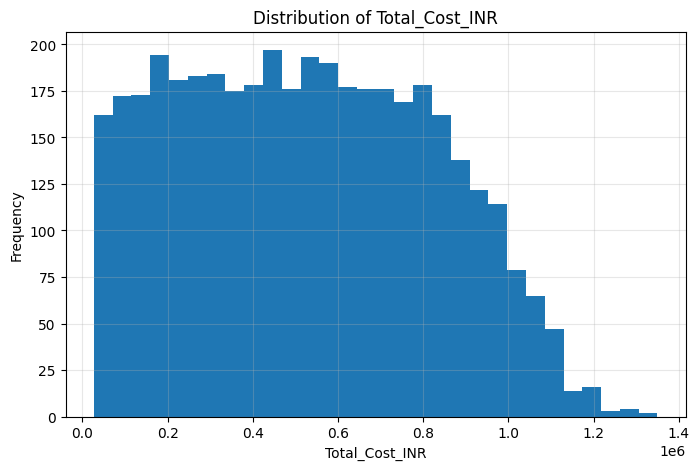

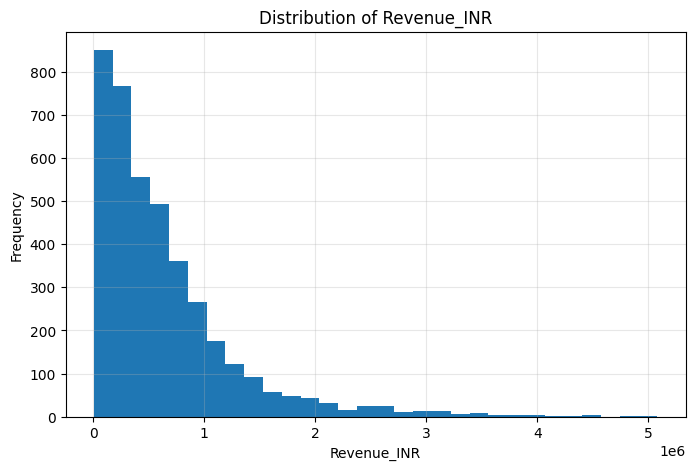

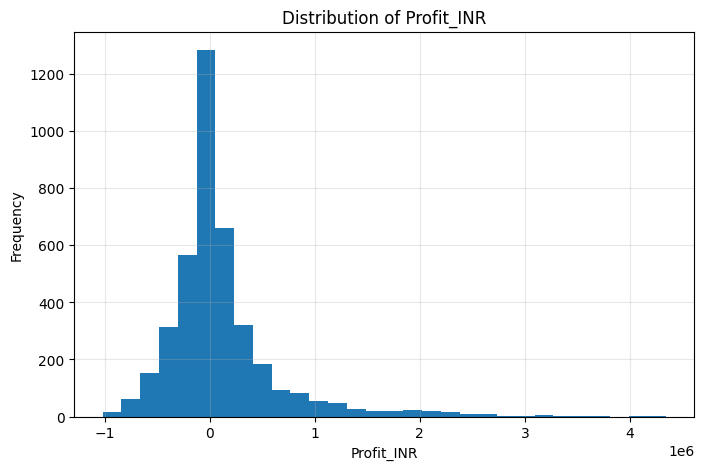

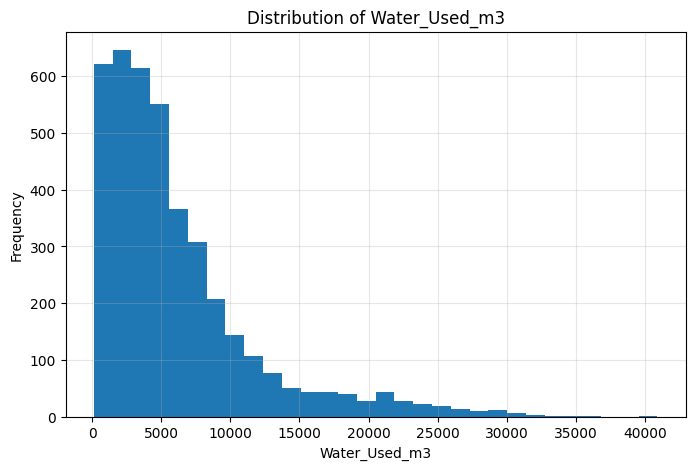

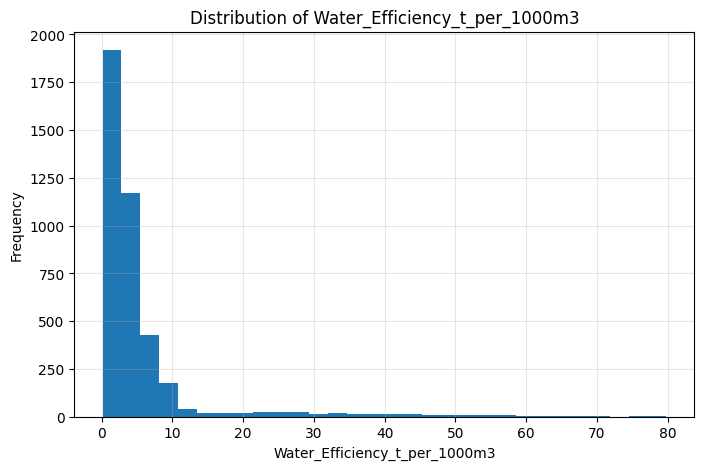

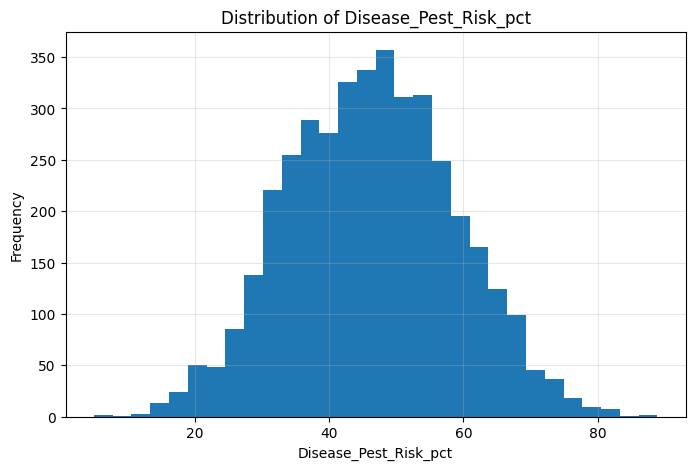

In [20]:
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

##12.2 Boxplots

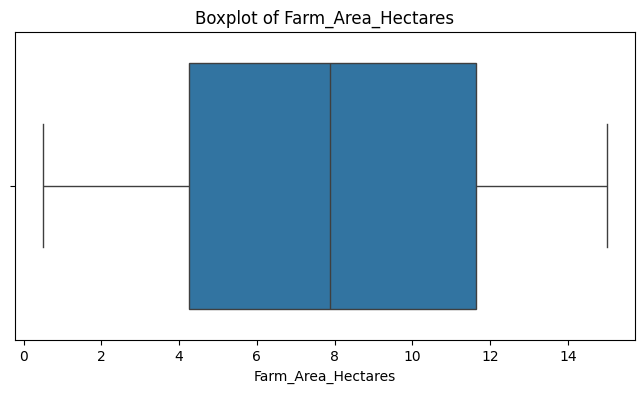

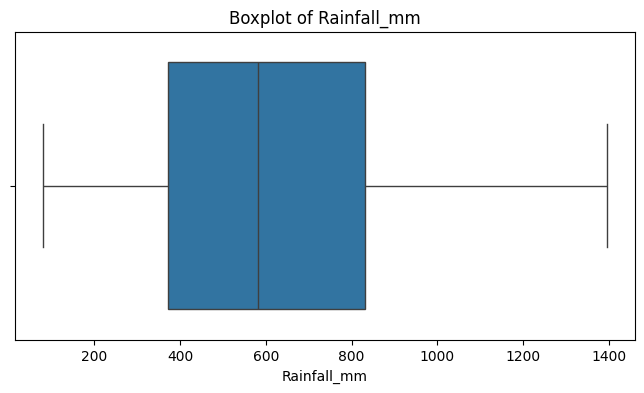

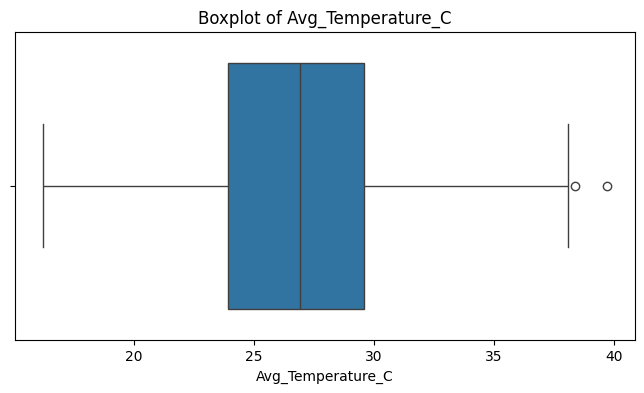

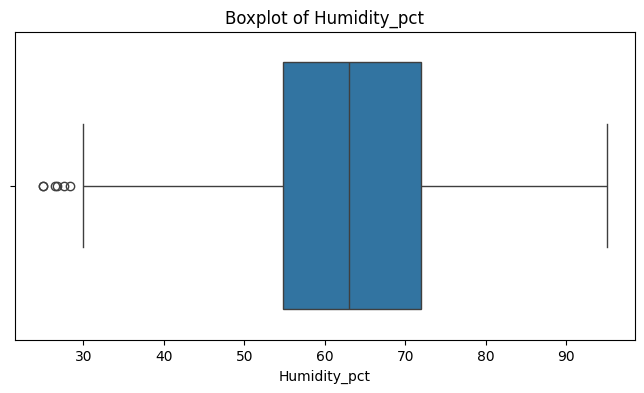

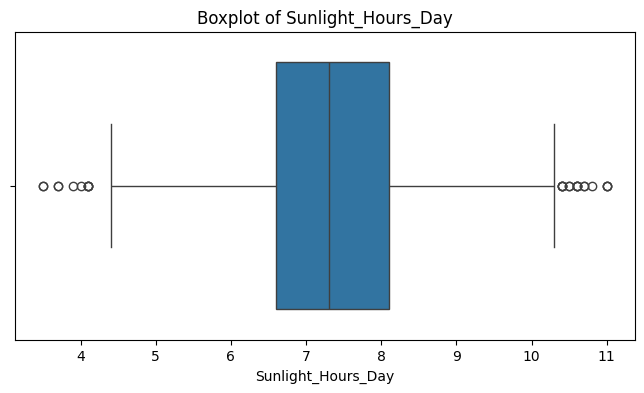

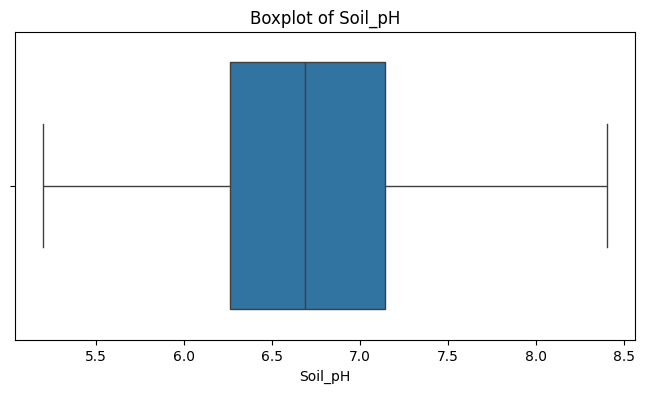

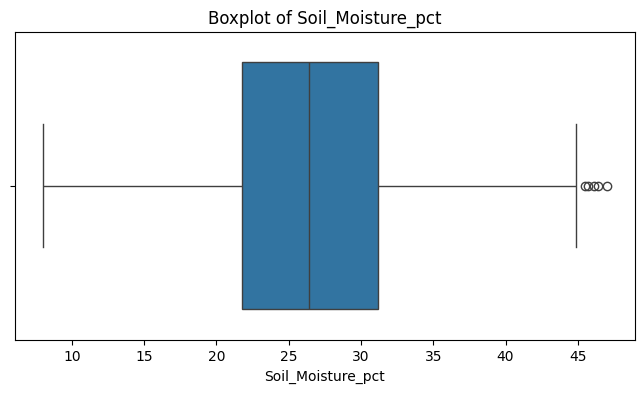

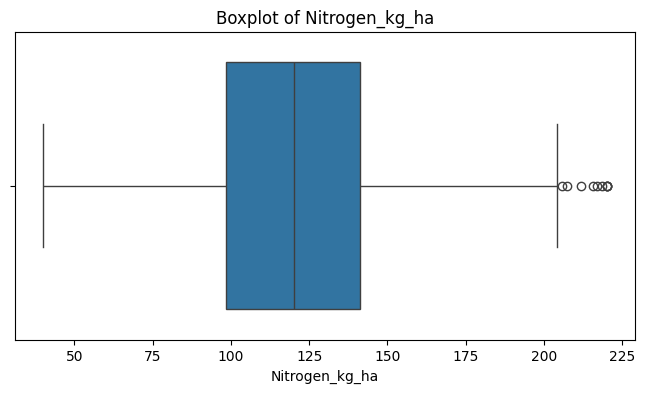

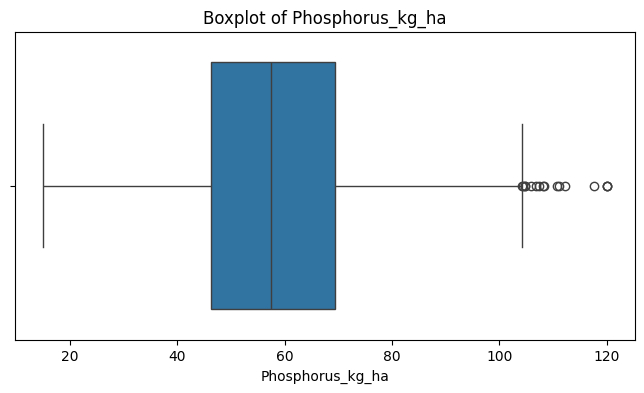

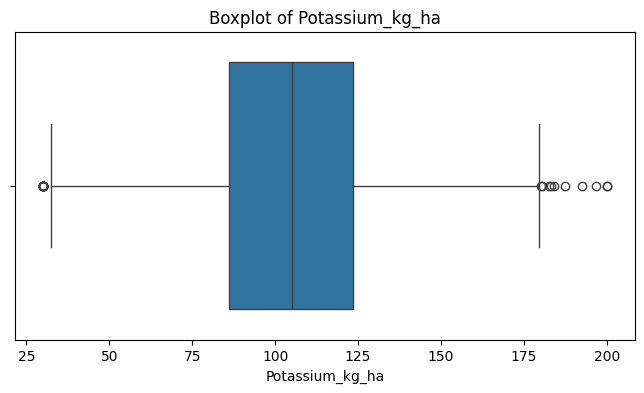

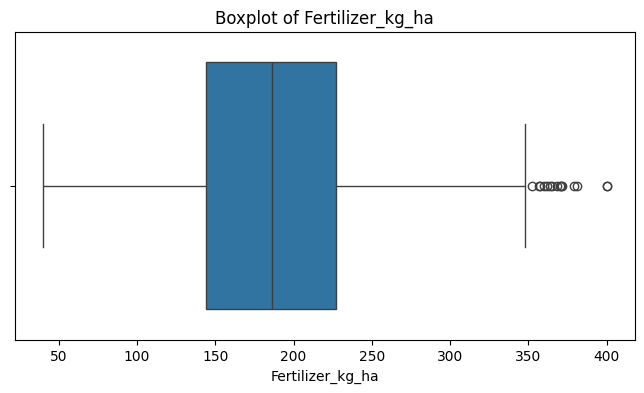

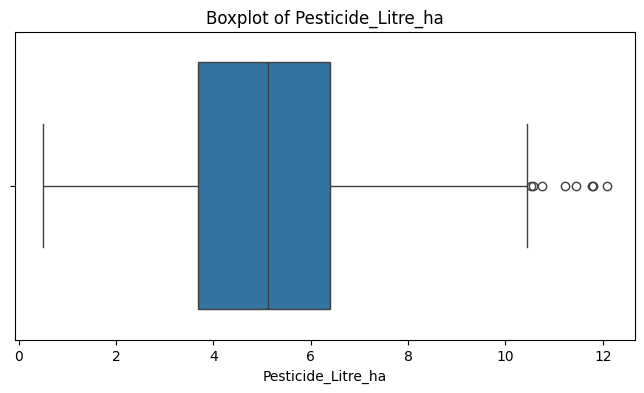

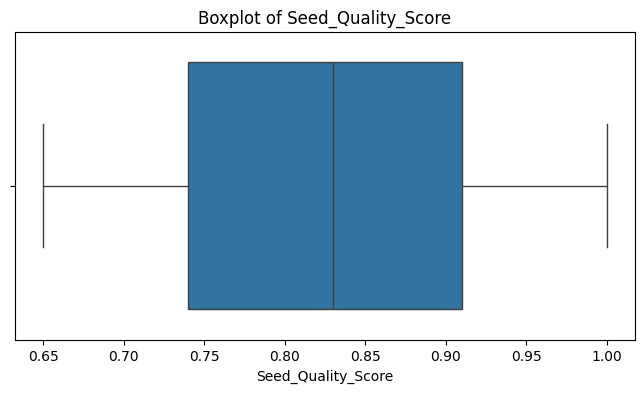

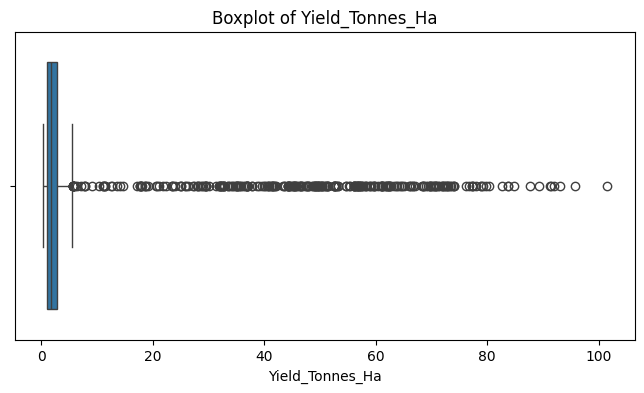

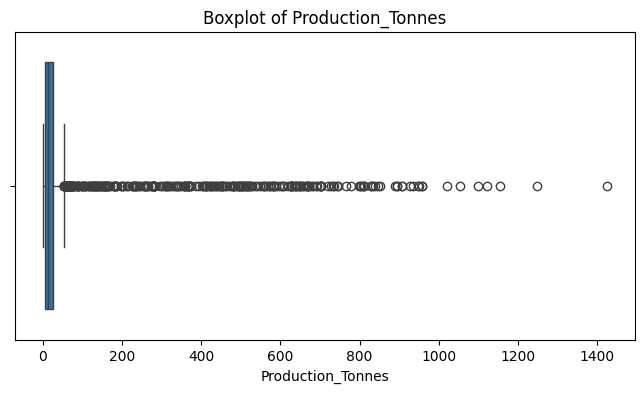

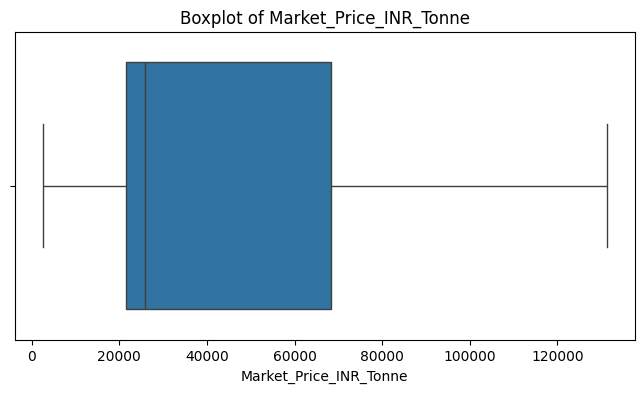

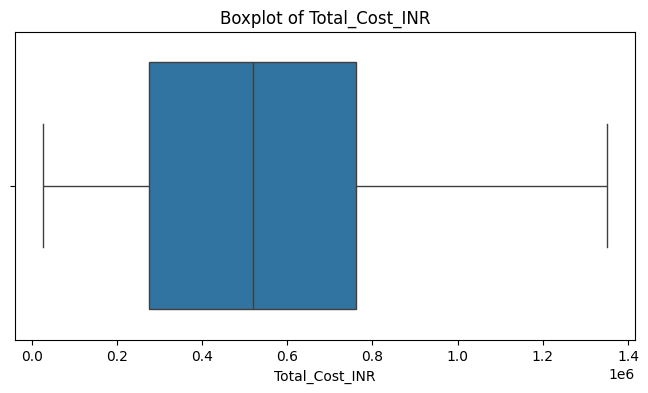

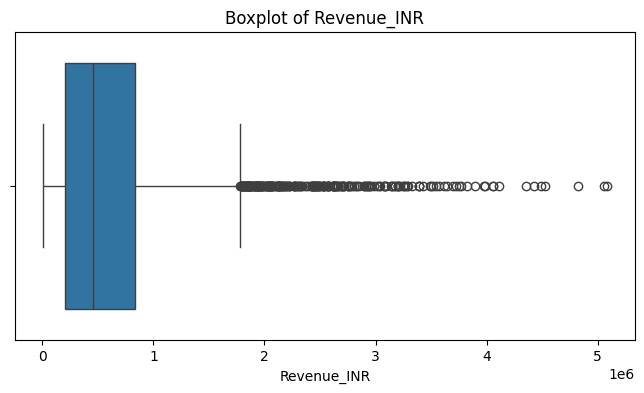

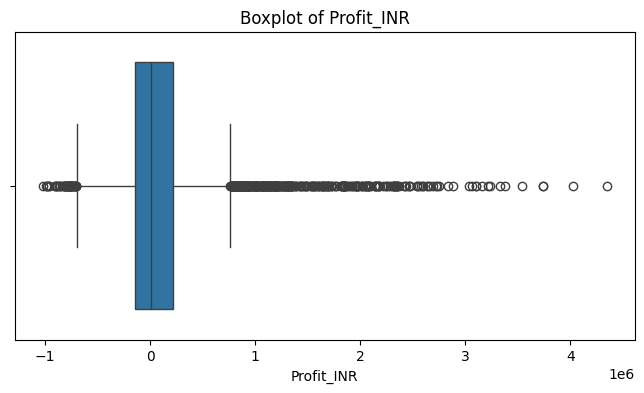

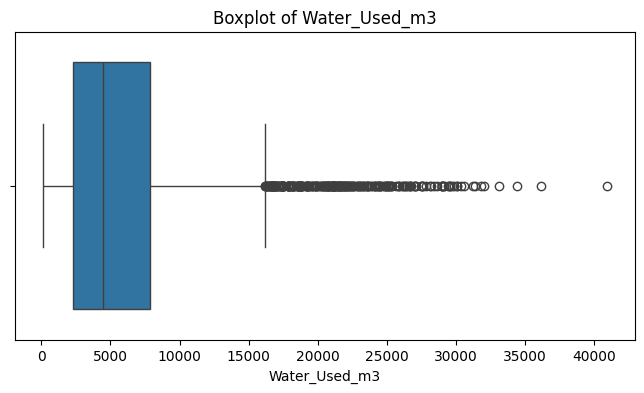

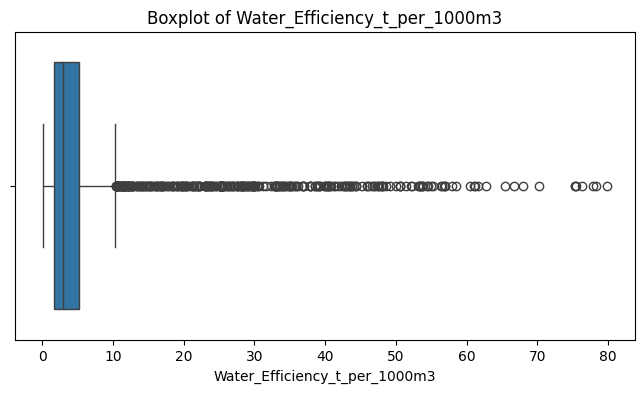

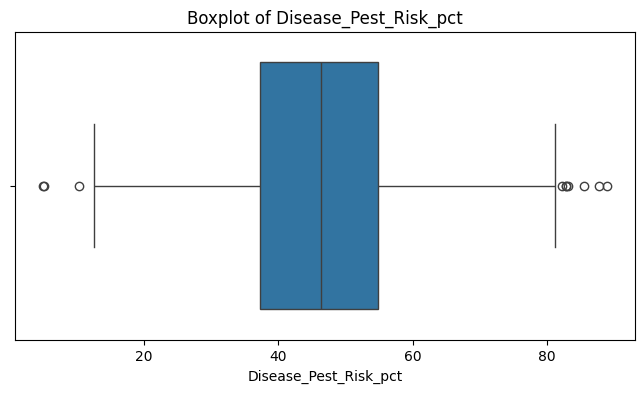

In [21]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

##13. Categorical Analysis

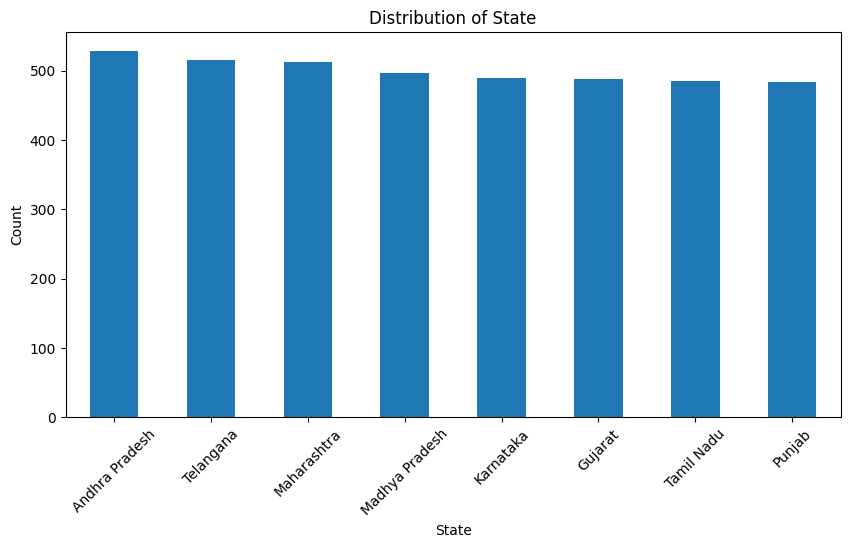

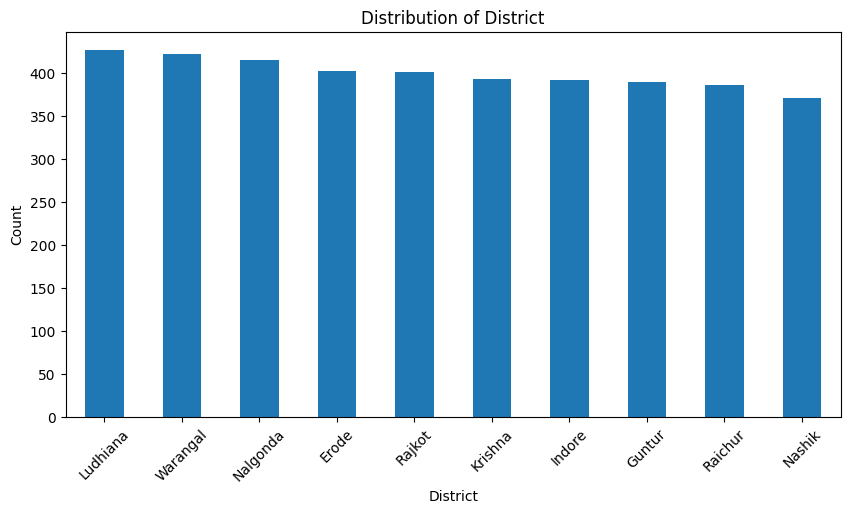

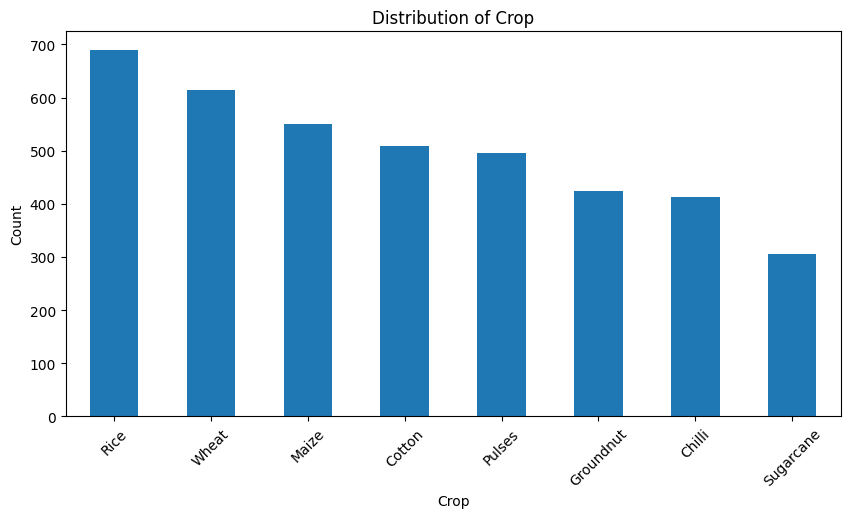

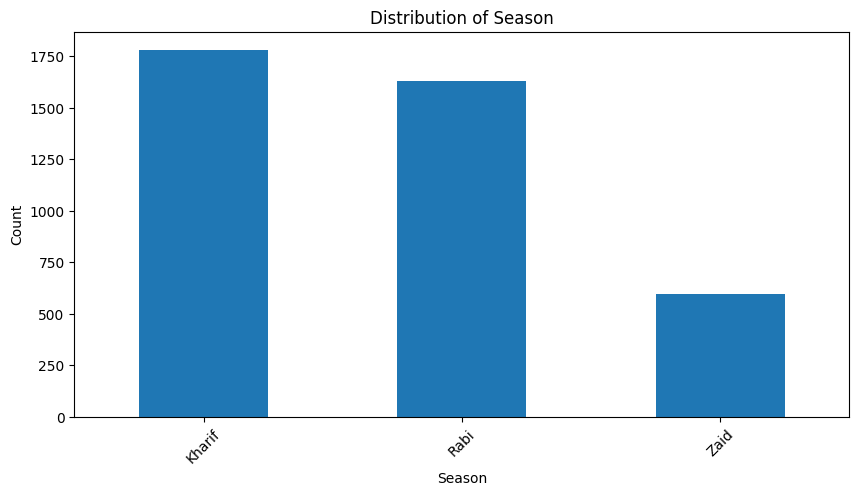

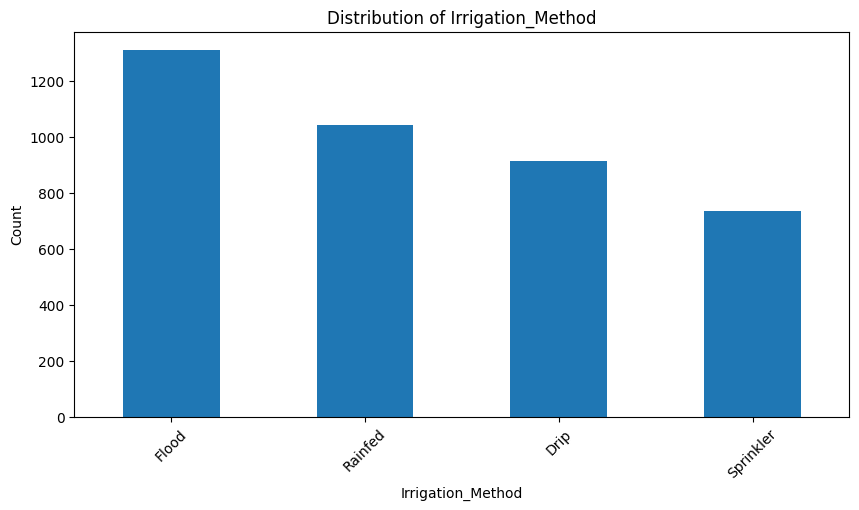

In [22]:
for col in categorical_cols:
    if df[col].nunique() <= 20:
        plt.figure(figsize=(10, 5))
        df[col].value_counts().plot(kind="bar")
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.show()

##14. Outlier Investigation

In [23]:
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": len(outliers),
        "Outlier %": round(len(outliers) / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Farm_Area_Hectares,4.260,11.65000,7.39000,-6.825000,2.273500e+01,0,0.00
1,Rainfall_mm,371.575,831.97500,460.40000,-319.025000,1.522575e+03,0,0.00
2,Avg_Temperature_C,23.900,29.60000,5.70000,15.350000,3.815000e+01,2,0.05
3,Humidity_pct,54.775,71.90000,17.12500,29.087500,9.758750e+01,6,0.15
4,Sunlight_Hours_Day,6.600,8.10000,1.50000,4.350000,1.035000e+01,26,0.65
5,Soil_pH,6.260,7.14000,0.88000,4.940000,8.460000e+00,0,0.00
6,Soil_Moisture_pct,21.800,31.20000,9.40000,7.700000,4.530000e+01,5,0.12
7,Nitrogen_kg_ha,98.500,141.22500,42.72500,34.412500,2.053125e+02,10,0.25
8,Phosphorus_kg_ha,46.200,69.40000,23.20000,11.400000,1.042000e+02,16,0.40
9,Potassium_kg_ha,86.200,123.60000,37.40000,30.100000,1.797000e+02,32,0.80


### Outlier Analysis

Outliers were investigated using the Interquartile Range (IQR) method.
Outliers were not automatically removed because extreme agricultural values
may represent genuine differences in crop production, cultivated area, yield,
or regional agricultural performance.

Therefore, extreme observations were retained unless they were identified
as obvious data-entry errors.

#15. Bivariate Analysis
##15.1 Categorical vs Numeric

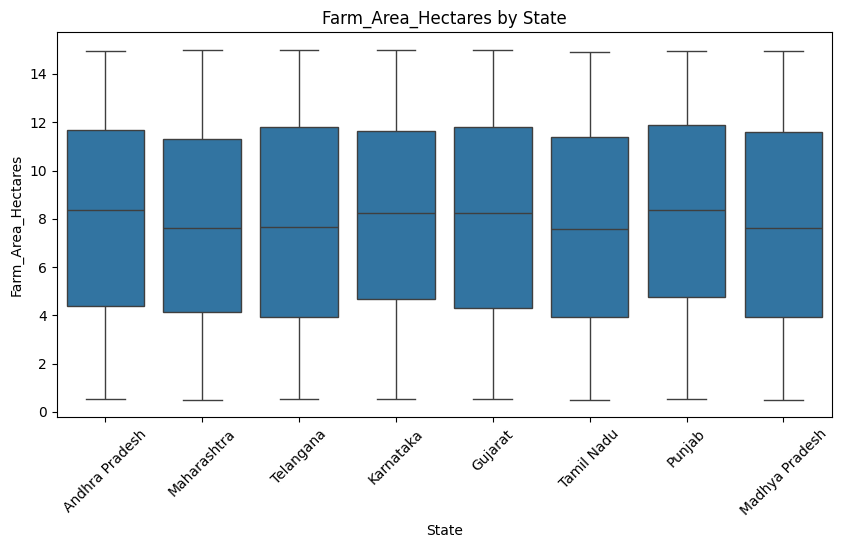

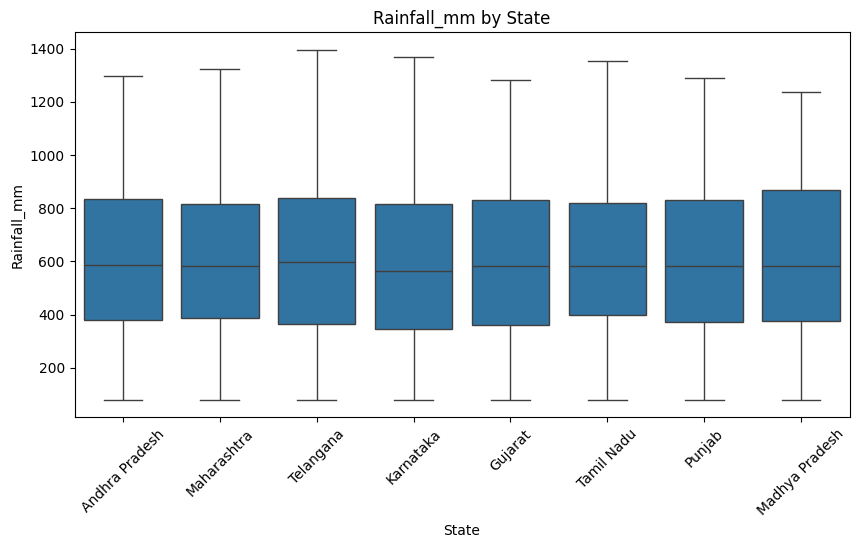

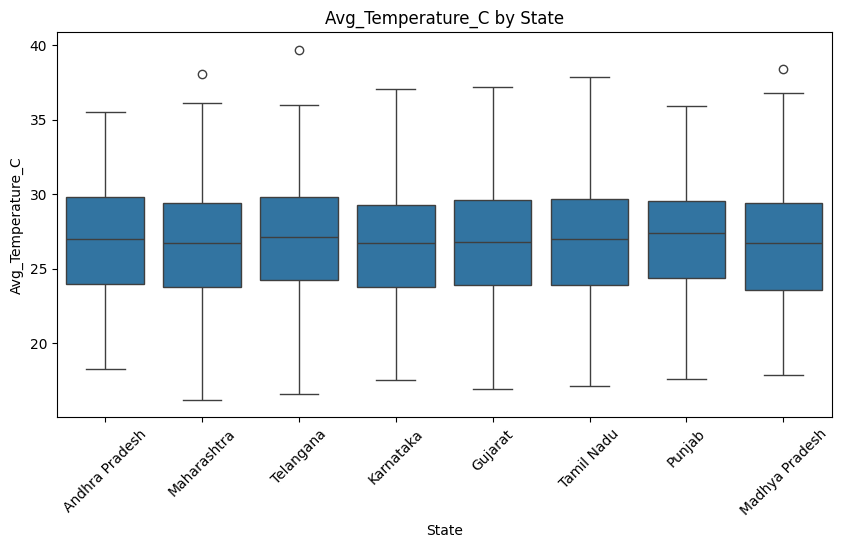

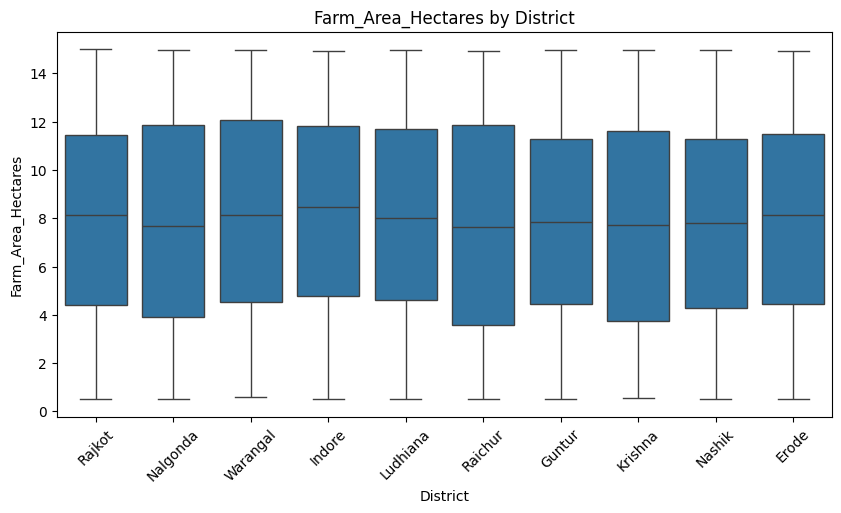

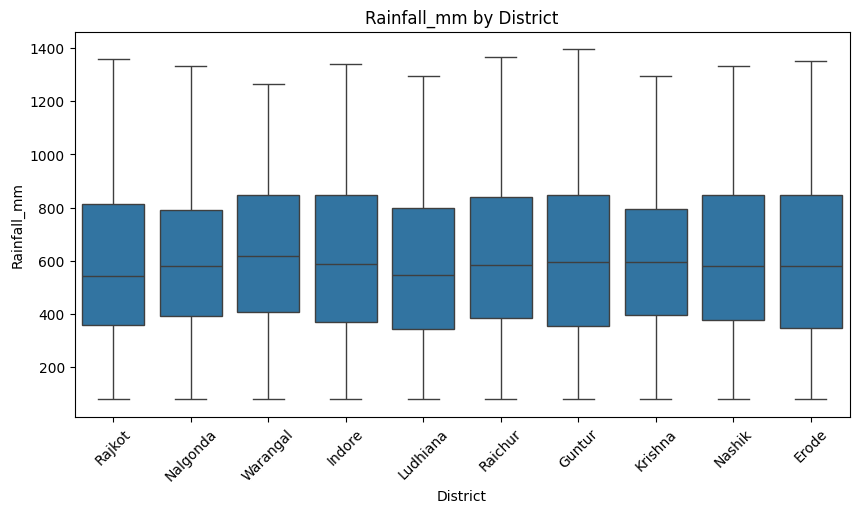

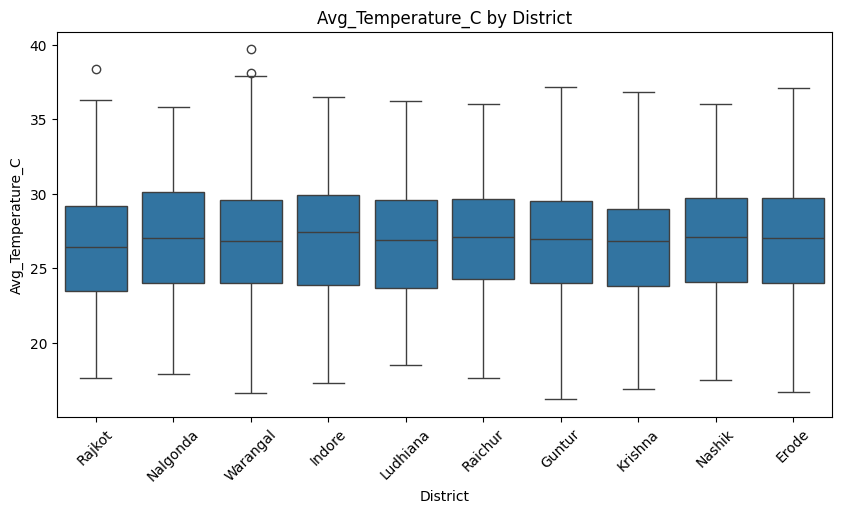

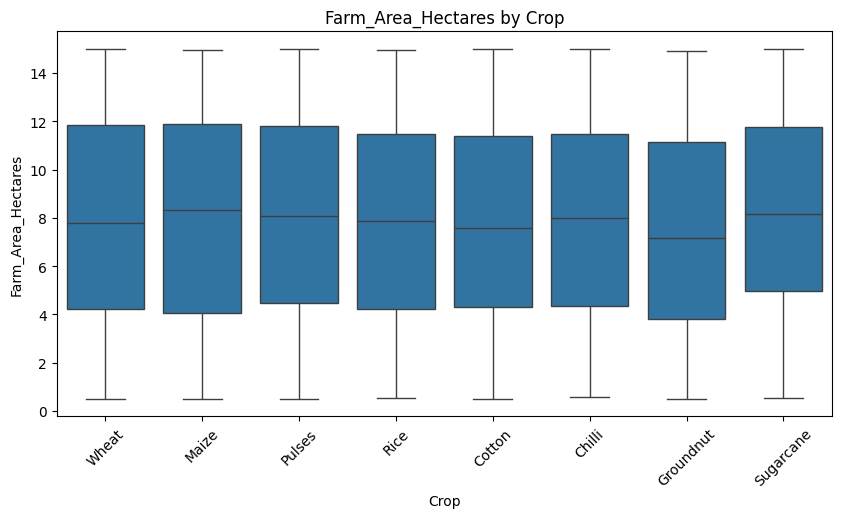

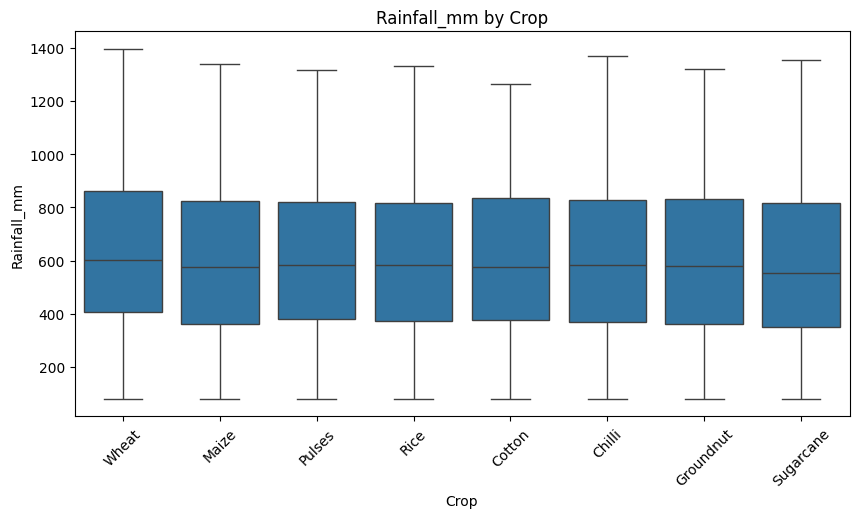

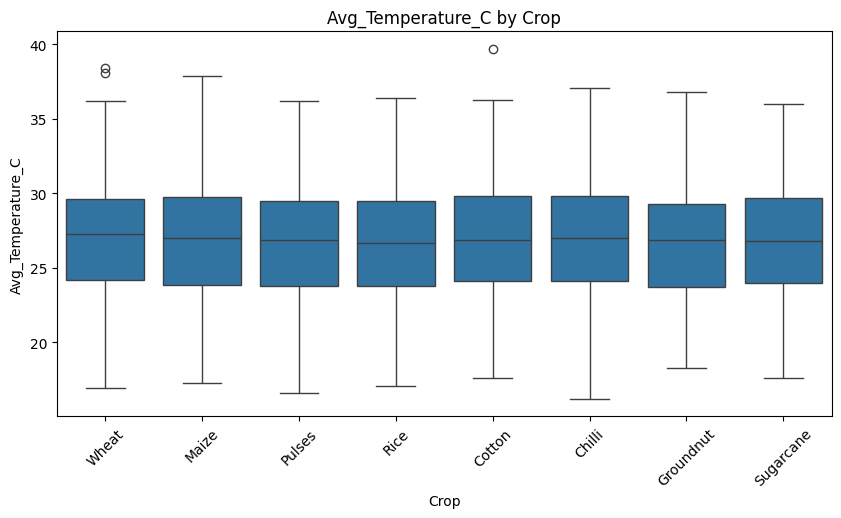

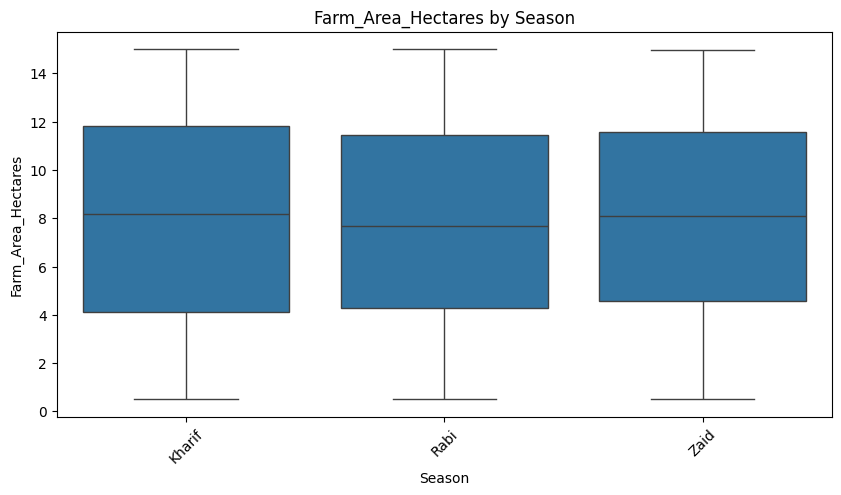

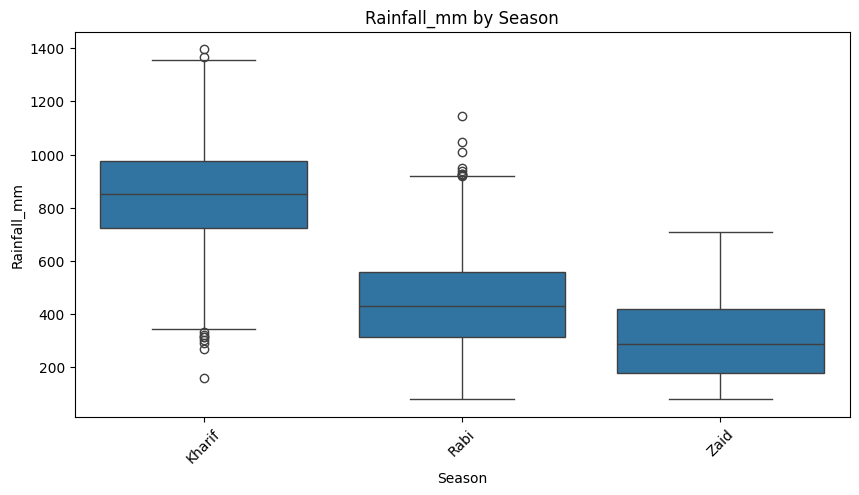

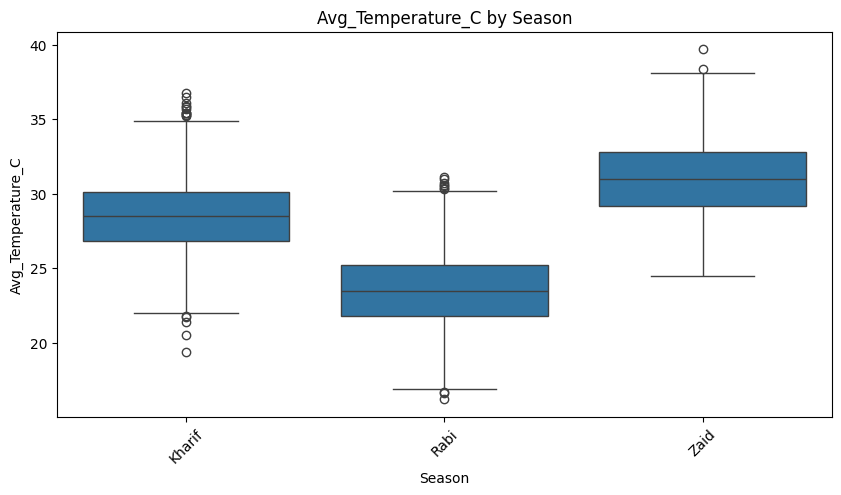

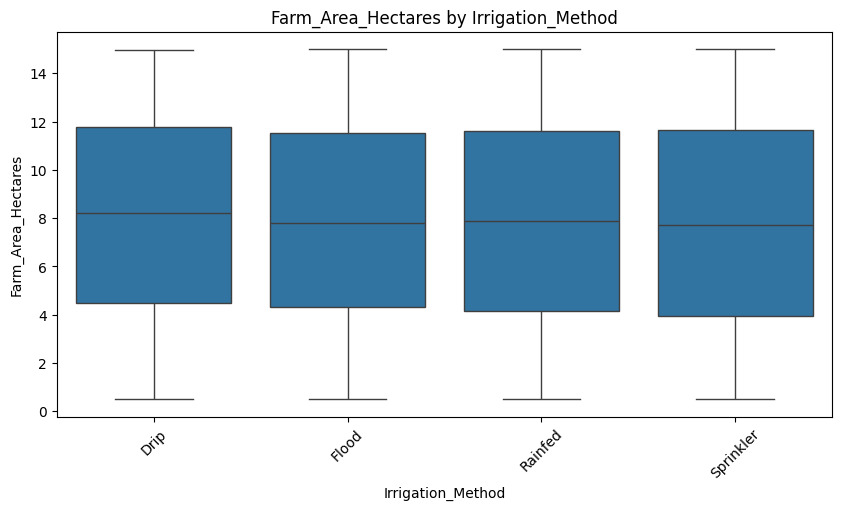

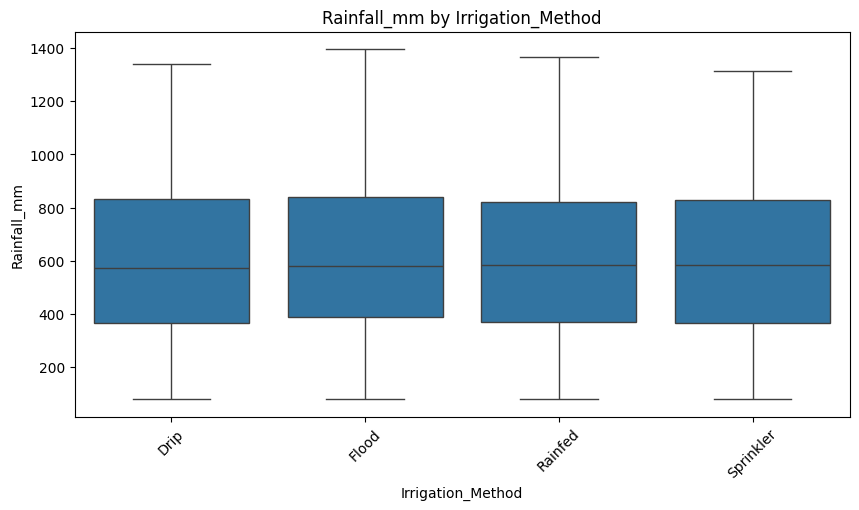

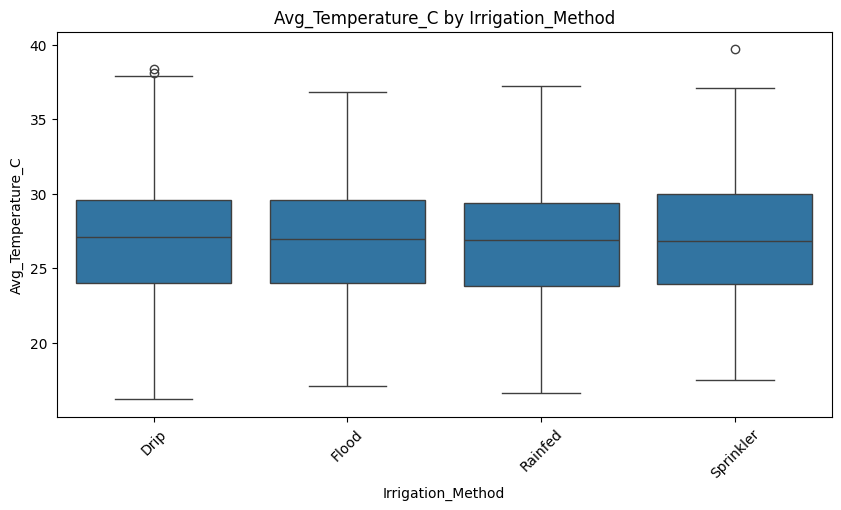

In [24]:
for cat in categorical_cols:
    if df[cat].nunique() <= 15:
        for num in numeric_cols[:3]:
            plt.figure(figsize=(10, 5))
            sns.boxplot(data=df, x=cat, y=num)
            plt.title(f"{num} by {cat}")
            plt.xticks(rotation=45)
            plt.show()

##16. Correlation Analysis

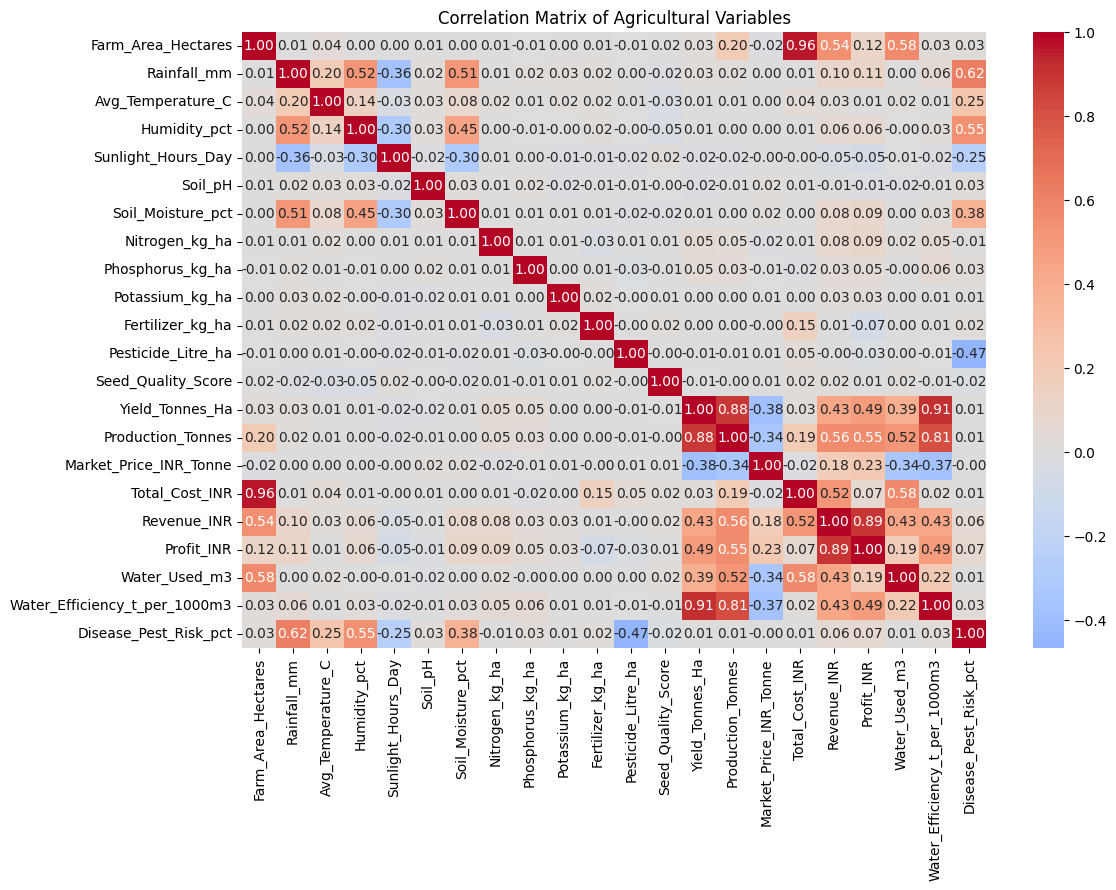

In [25]:
correlation = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Agricultural Variables")
plt.show()

##17. Find Strongest Correlations

In [26]:
corr_pairs = correlation.unstack()

corr_pairs = corr_pairs[
    corr_pairs.index.get_level_values(0) !=
    corr_pairs.index.get_level_values(1)
]

corr_pairs = corr_pairs.sort_values(
    key=lambda x: abs(x),
    ascending=False
)

display(corr_pairs.head(10))

,,0
Total_Cost_INR,Farm_Area_Hectares,0.962211
Farm_Area_Hectares,Total_Cost_INR,0.962211
Water_Efficiency_t_per_1000m3,Yield_Tonnes_Ha,0.912568
Yield_Tonnes_Ha,Water_Efficiency_t_per_1000m3,0.912568
Profit_INR,Revenue_INR,0.887331
Revenue_INR,Profit_INR,0.887331
Production_Tonnes,Yield_Tonnes_Ha,0.882813
Yield_Tonnes_Ha,Production_Tonnes,0.882813
Production_Tonnes,Water_Efficiency_t_per_1000m3,0.812143
Water_Efficiency_t_per_1000m3,Production_Tonnes,0.812143


##18. Multivariate Analysis

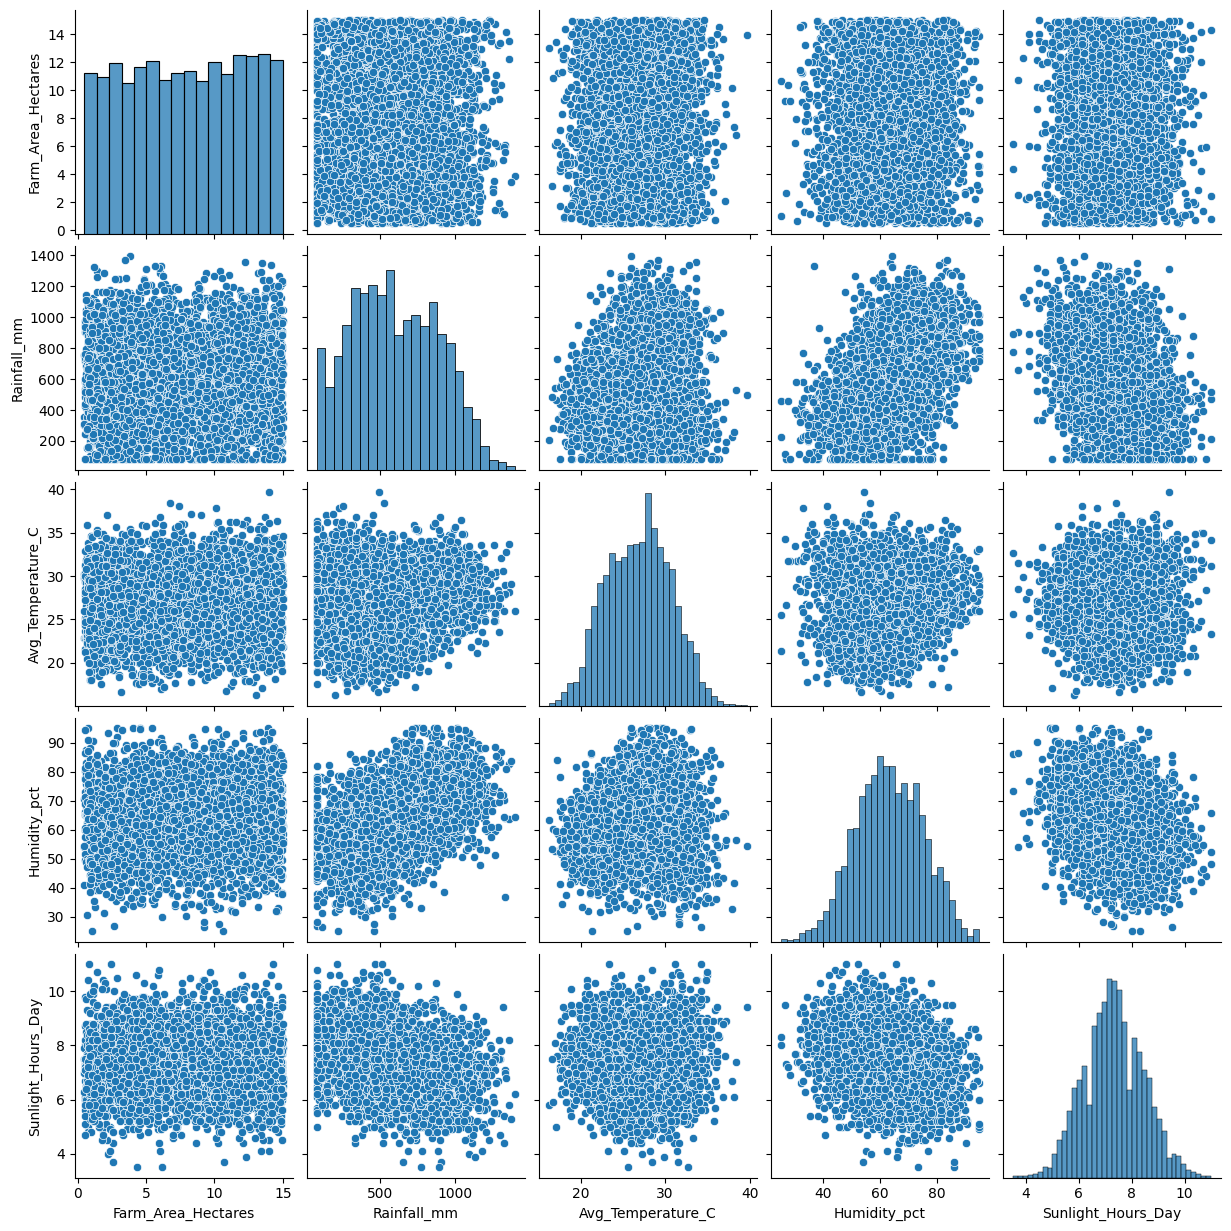

In [27]:
if len(numeric_cols) >= 3:
    sns.pairplot(
        df[numeric_cols[:5]].dropna()
    )
    plt.show()

##19. Scatter Plot Analysis

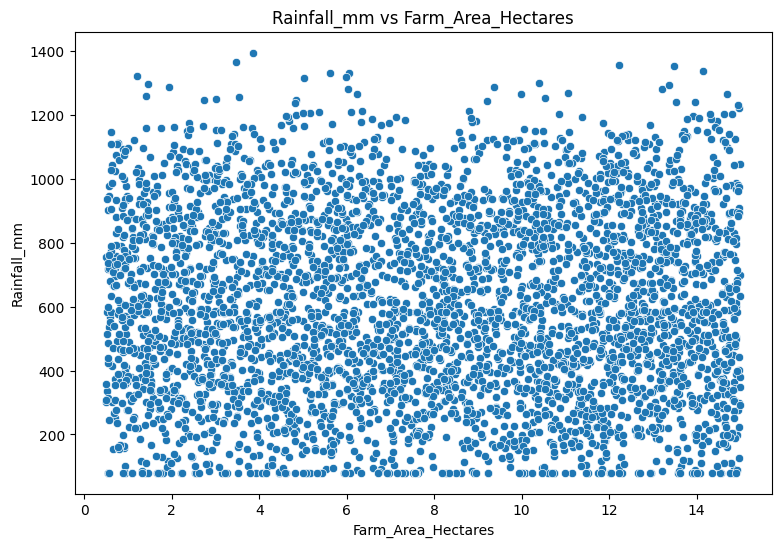

In [28]:
if len(numeric_cols) >= 2:

    x = numeric_cols[0]
    y = numeric_cols[1]

    plt.figure(figsize=(9, 6))

    sns.scatterplot(
        data=df,
        x=x,
        y=y
    )

    plt.title(f"{y} vs {x}")
    plt.show()

##20. Seasonal Analysis

This is particularly important because your project is about Seasonal Agriculture Performance.

First identify the season column.

In [29]:
possible_season_cols = [
    col for col in df.columns
    if "season" in col.lower()
]

print("Possible season columns:")
print(possible_season_cols)

Possible season columns:
['Season']


In [30]:
season_col = "Season"

print(df[season_col].value_counts())

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


##21. Agricultural Performance by Season

In [31]:
season_summary = df.groupby(season_col)[numeric_cols].mean()

display(season_summary)

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,,,,,,,,,,,,,,,
Kharif,7.944924,849.199663,28.454019,71.812591,6.793367,6.727993,31.149859,120.020124,58.096515,105.303485,187.077965,5.079747,0.821613,5.628612,46.311192,44850.906127,531804.408094,710719.055649,178914.647555,6102.201237,5.891834,54.467903
Rabi,7.752207,437.615366,23.489183,57.893178,7.589797,6.673749,24.069392,120.402827,57.311002,103.926060,185.407068,5.024690,0.832170,5.039435,41.486712,44747.974800,513836.578365,601526.048556,87689.470191,5846.987093,5.186122,40.482114
Zaid,8.091246,304.654714,31.042088,52.012121,8.178788,6.694865,19.279630,120.525421,58.129125,105.416835,184.638047,5.171212,0.823165,4.641313,38.886111,44212.033670,543976.728956,519171.904040,-24804.824916,6419.893939,4.413239,38.216667


##22. Seasonal Comparison Chart

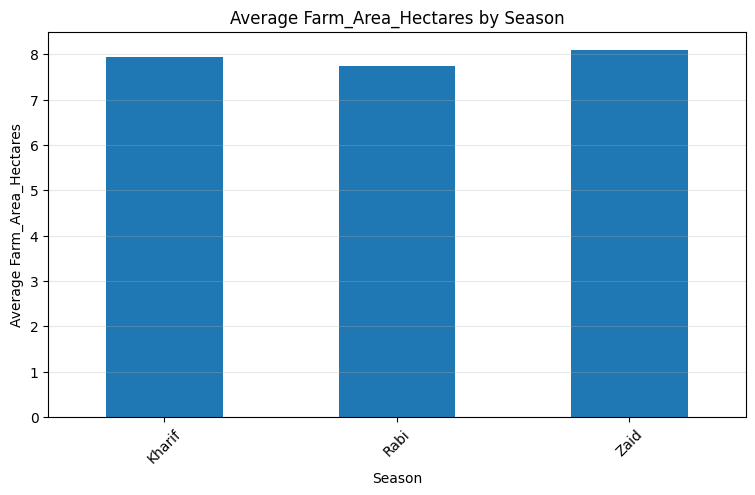

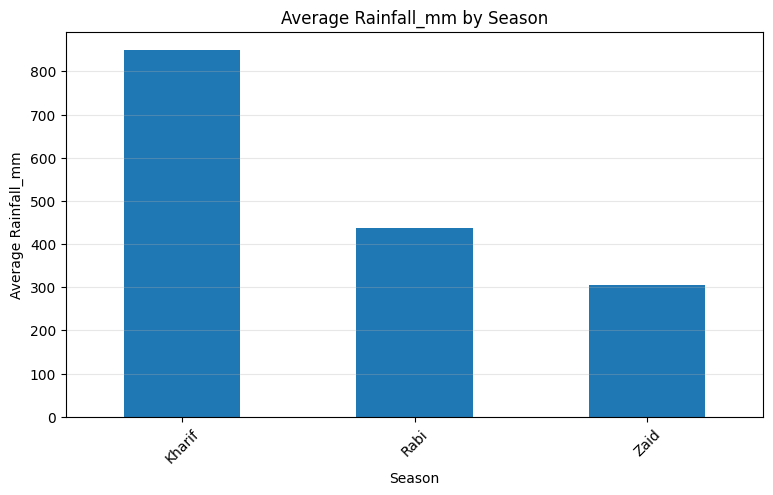

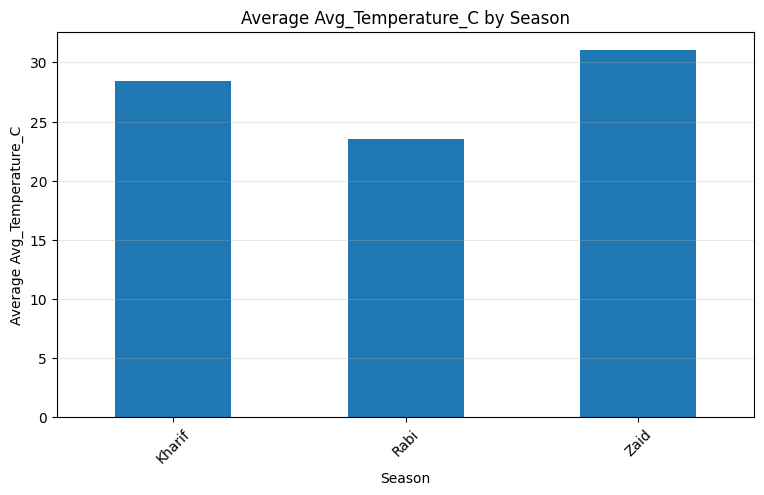

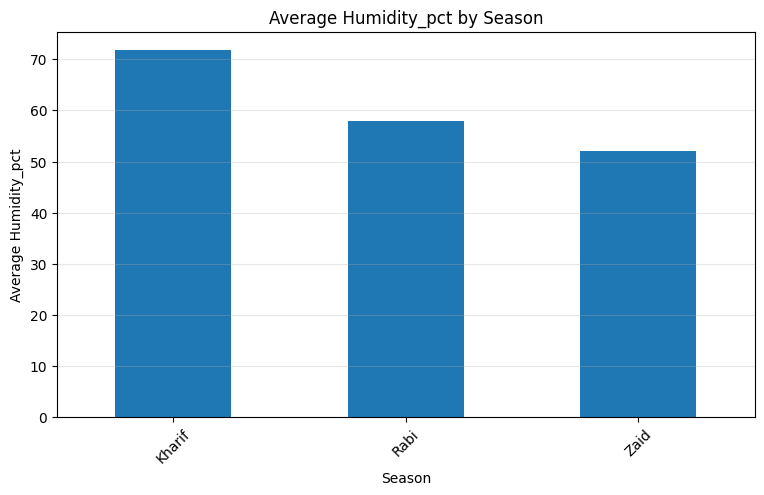

In [32]:
for col in numeric_cols[:4]:

    plt.figure(figsize=(9, 5))

    season_summary[col].plot(kind="bar")

    plt.title(f"Average {col} by Season")
    plt.xlabel("Season")
    plt.ylabel(f"Average {col}")
    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.3)

    plt.show()

##23. Student-Designed Analysis 1
Best Performing Season

In [33]:
# Replace with your main performance variable
performance_col = "Profit_INR"

season_performance = (
    df.groupby("Season")[performance_col]
    .mean()
    .sort_values(ascending=False)
)

display(season_performance)

,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


In [34]:
# Crop-wise average profit

crop_performance = (
    df.groupby("Crop")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

display(crop_performance)

,Profit_INR
Crop,
Sugarcane,817187.986885
Chilli,750878.342233
Cotton,124546.915354
Groundnut,44858.120283
Pulses,-4238.052419
Maize,-83978.326679
Rice,-102213.504348
Wheat,-123398.337134


##Chart

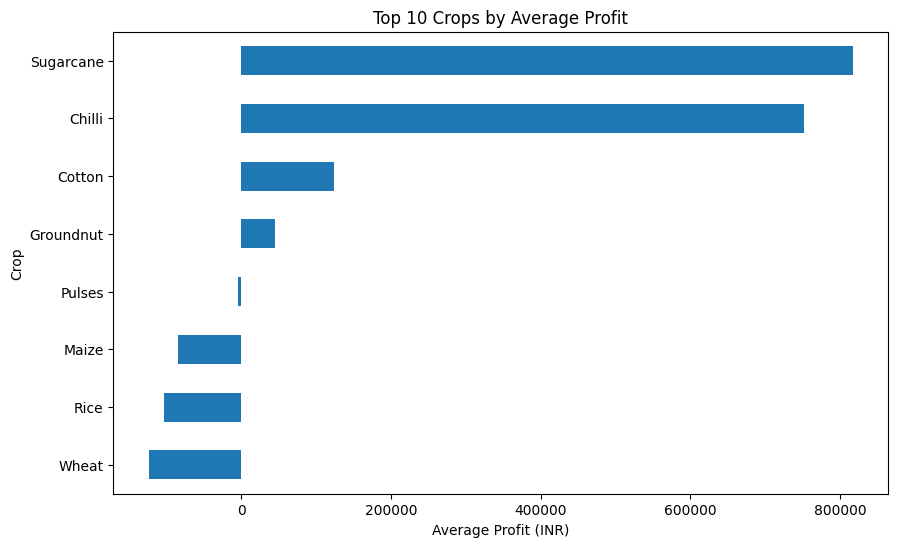

In [35]:
plt.figure(figsize=(10, 6))

crop_performance.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Crops by Average Profit")
plt.xlabel("Average Profit (INR)")
plt.ylabel("Crop")

plt.show()

### Student-Designed Analysis 1: Seasonal Performance

The analysis compares agricultural performance across different seasons.
The season with the highest average performance can be considered the
most favorable season for the selected agricultural indicator.

##24. Student-Designed Analysis 2
Top Performing Crops

Find crop column:

In [36]:
possible_crop_cols = [
    col for col in df.columns
    if "crop" in col.lower()
]

print(possible_crop_cols)

['Crop']


In [37]:
crop_col = "Crop"

crop_performance = (
    df.groupby(crop_col)[performance_col]
    .mean()
    .sort_values(ascending=False)
)

display(crop_performance.head(10))

,Profit_INR
Crop,
Sugarcane,817187.986885
Chilli,750878.342233
Cotton,124546.915354
Groundnut,44858.120283
Pulses,-4238.052419
Maize,-83978.326679
Rice,-102213.504348
Wheat,-123398.337134


##Chart

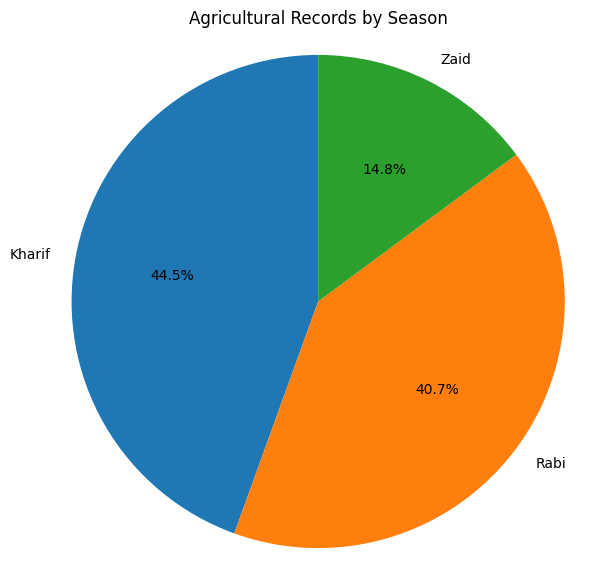

In [53]:
import matplotlib.pyplot as plt

# Count records by season
season_counts = df["Season"].value_counts()

# Pie chart
plt.figure(figsize=(7, 7))

plt.pie(
    season_counts.values,
    labels=season_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Agricultural Records by Season")
plt.axis("equal")
plt.show()

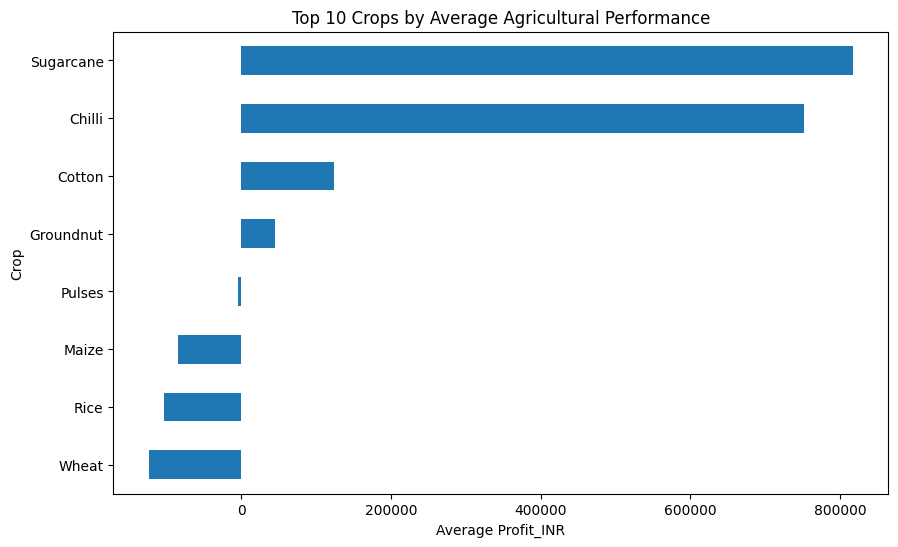

In [38]:
plt.figure(figsize=(10, 6))

crop_performance.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Crops by Average Agricultural Performance")
plt.xlabel(f"Average {performance_col}")
plt.ylabel("Crop")

plt.show()

### Student-Designed Analysis 2: Crop Performance

The crop-level analysis identifies crops with the highest average
agricultural performance. These crops may have better suitability
for the environmental and seasonal conditions represented in the dataset.

##25. Student-Designed Analysis 3
Season × Crop Analysis

In [39]:
# Average profit by Crop and Season

season_crop = pd.pivot_table(
    df,
    values="Profit_INR",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

display(season_crop)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,9.543804e+05,638572.496933,448659.093750
Cotton,2.169995e+05,107343.587065,-53925.336957
Groundnut,1.082654e+05,10416.542373,-68872.500000
Maize,-3.933267e+04,-89133.403433,-194049.166667
Pulses,4.333890e+04,-14309.136150,-139227.806452
Rice,-6.490340e+04,-98427.868613,-227239.343137
Sugarcane,1.000791e+06,731612.860465,583635.803922
Wheat,-1.058719e+05,-119954.565401,-193208.952941


##Heatmap

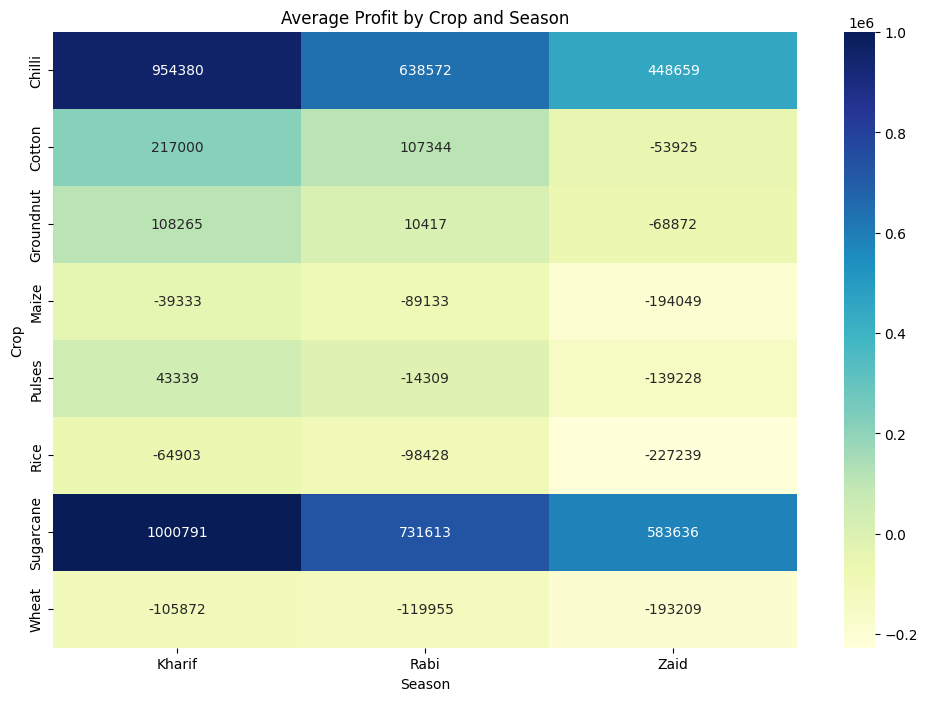

In [40]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    season_crop,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Average Profit by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.show()

### Student-Designed Analysis 3: Crop-Season Interaction

The crop-season analysis identifies whether agricultural performance
changes depending on both crop type and season.

This analysis is useful for identifying crop-season combinations
that consistently produce better outcomes.

##26. Top 10 Agricultural Records

In [41]:
top_records = df.sort_values(
    performance_col,
    ascending=False
).head(10)

display(top_records)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
2236,SF12237,Punjab,Rajkot,Chilli,Kharif,12.74,723.4,26.2,69.0,7.1,6.85,26.4,132.9,90.9,137.5,Flood,186.3,4.52,0.77,3.90,49.69,101780,712027,5057448,4345421,10398,4.779,52.3
626,SF10627,Maharashtra,Warangal,Chilli,Kharif,14.45,806.5,28.9,68.9,8.6,6.48,27.1,131.6,75.4,120.6,Flood,182.9,2.52,0.94,2.92,42.19,120429,1059050,5080900,4021850,10980,3.842,58.0
3425,SF13426,Madhya Pradesh,Rajkot,Sugarcane,Kharif,13.96,879.1,29.8,76.1,5.6,6.73,18.5,117.9,73.0,86.5,Drip,117.2,7.14,0.88,82.68,1154.21,3886,745161,4485260,3740099,23472,49.174,64.6
1690,SF11691,Karnataka,Warangal,Chilli,Kharif,13.04,921.0,28.4,77.6,6.5,6.65,39.2,141.1,46.1,96.0,Drip,163.1,4.65,0.97,3.01,39.25,115222,784135,4522464,3738329,7074,5.548,47.4
247,SF10248,Maharashtra,Krishna,Chilli,Kharif,14.86,566.3,27.6,69.4,6.4,6.41,30.1,166.0,28.7,104.4,Flood,199.3,7.14,0.69,3.09,45.92,105082,1283161,4825365,3542204,12869,3.568,40.2
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,14.74,589.1,24.2,54.5,8.0,6.81,19.1,151.3,80.3,127.8,Sprinkler,187.3,4.43,0.98,84.75,1249.21,3483,972119,4350998,3378879,23936,52.190,43.8
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,14.87,745.9,29.6,74.1,6.4,6.52,28.8,115.4,53.9,109.1,Drip,200.4,7.35,0.82,95.79,1424.40,3109,1097878,4428460,3330582,23289,61.162,42.7
1930,SF11931,Tamil Nadu,Guntur,Sugarcane,Kharif,14.16,860.4,26.5,74.0,5.0,7.14,29.7,157.2,66.1,151.7,Drip,122.0,5.71,0.73,79.25,1122.18,3661,875331,4108301,3232970,21133,53.101,41.8
3983,SF13984,Gujarat,Nashik,Chilli,Kharif,13.68,717.2,29.3,66.4,7.8,6.66,31.8,100.2,49.9,129.4,Drip,128.9,6.71,0.82,3.02,41.31,98175,844264,4055609,3211345,7219,5.722,49.6
263,SF10264,Maharashtra,Ludhiana,Chilli,Rabi,13.95,866.6,27.4,49.1,8.5,7.13,29.5,183.9,48.2,78.0,Sprinkler,182.4,3.33,0.85,2.53,35.29,112997,828217,3987664,3159447,8108,4.352,56.3


##27. Bottom 10 Agricultural Records

In [42]:
bottom_records = df.sort_values(
    performance_col,
    ascending=True
).head(10)

display(bottom_records)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
780,SF10781,Andhra Pradesh,Ludhiana,Groundnut,Rabi,14.64,170.8,22.1,62.7,7.6,8.40,19.2,79.8,60.8,146.7,Sprinkler,322.3,5.99,0.68,0.30,4.39,63813,1299362,280139,-1019223,7779,0.564,29.3
2210,SF12211,Andhra Pradesh,Raichur,Wheat,Rabi,14.27,347.6,22.7,54.4,7.9,5.20,21.2,121.8,57.3,126.2,Drip,290.6,5.82,0.81,0.30,4.28,23948,1097692,102497,-995195,6506,0.658,42.5
3625,SF13626,Punjab,Krishna,Maize,Rabi,13.47,439.1,19.5,54.5,7.0,5.70,25.9,58.2,51.9,117.2,Flood,246.6,8.88,0.70,0.97,13.07,17330,1207553,226503,-981050,9675,1.351,27.7
2182,SF12183,Andhra Pradesh,Krishna,Rice,Kharif,14.72,812.4,29.3,72.9,7.1,7.73,34.5,123.5,62.9,61.7,Flood,264.8,5.01,0.82,1.01,14.87,21578,1297725,320865,-976860,25877,0.575,40.8
104,SF10105,Gujarat,Krishna,Wheat,Zaid,12.30,80.0,30.5,61.2,10.2,5.44,16.8,100.3,53.0,125.6,Flood,302.3,5.90,0.87,0.30,3.69,26773,1063989,98792,-965197,9826,0.376,31.3
3394,SF13395,Gujarat,Erode,Wheat,Kharif,13.41,634.3,25.2,77.8,7.5,5.20,27.5,117.5,62.3,112.6,Flood,272.4,5.33,0.85,0.30,4.02,24787,1063040,99644,-963396,9139,0.440,44.8
2730,SF12731,Madhya Pradesh,Ludhiana,Rice,Rabi,11.99,535.0,21.7,64.0,6.2,8.19,26.5,121.0,40.4,93.1,Sprinkler,222.2,5.18,0.86,1.74,3.60,24777,995279,89197,-906082,18723,0.192,35.4
1311,SF11312,Punjab,Rajkot,Rice,Zaid,13.55,152.9,29.2,44.4,7.8,5.49,26.0,96.4,41.5,95.3,Drip,234.7,3.48,0.75,0.45,6.10,26735,1065824,163084,-902740,15849,0.385,21.2
585,SF10586,Telangana,Warangal,Cotton,Zaid,13.96,496.6,39.7,54.4,9.4,8.01,14.9,122.5,57.2,117.8,Sprinkler,226.4,6.04,0.98,0.30,4.19,47327,1094030,198300,-895730,10015,0.418,41.6
3090,SF13091,Karnataka,Ludhiana,Maize,Kharif,14.39,1028.8,28.8,59.4,6.2,5.33,23.6,94.6,56.3,114.4,Drip,206.5,5.86,0.98,0.41,5.90,18479,999667,109026,-890641,8044,0.733,51.3


##28. Average Performance

In [43]:
print(
    f"Average {performance_col}:",
    round(df[performance_col].mean(), 2)
)

print(
    f"Median {performance_col}:",
    round(df[performance_col].median(), 2)
)

print(
    f"Maximum {performance_col}:",
    round(df[performance_col].max(), 2)
)

print(
    f"Minimum {performance_col}:",
    round(df[performance_col].min(), 2)
)

Average Profit_INR: 111556.46
Median Profit_INR: 3673.0
Maximum Profit_INR: 4345421
Minimum Profit_INR: -1019223


##29. Variability Analysis

In [44]:
variability = df[numeric_cols].agg(
    ["mean", "median", "std", "min", "max"]
).T

variability["CV %"] = (
    variability["std"] /
    variability["mean"].replace(0, np.nan)
) * 100

display(variability.sort_values("CV %", ascending=False))

,mean,median,std,min,max,CV %
Profit_INR,111556.465000,3673.0000,545081.890509,-1019223.000,4345421.00,488.615241
Production_Tonnes,43.246210,11.7700,126.880521,0.150,1424.40,293.391076
Yield_Tonnes_Ha,5.242350,1.7400,13.311549,0.300,101.44,253.923308
Water_Efficiency_t_per_1000m3,5.385214,2.9375,8.838101,0.135,79.80,164.117906
Revenue_INR,637860.048000,456830.5000,636974.710054,6107.000,5080900.00,99.861202
Water_Used_m3,6045.570250,4435.0000,5572.944306,128.000,40902.00,92.182277
Market_Price_INR_Tonne,44714.166250,25913.0000,30266.161922,2594.000,131240.00,67.688083
Total_Cost_INR,526303.583000,519082.5000,294419.140911,26826.000,1349990.00,55.940934
Farm_Area_Hectares,7.888265,7.8950,4.223764,0.500,15.00,53.544902
Rainfall_mm,600.922825,582.0000,287.193381,80.000,1395.20,47.792057


##30. Regional Analysis

In [45]:
possible_region_cols = [
    col for col in df.columns
    if any(word in col.lower()
           for word in ["state", "region", "district", "location", "area"])
]

print(possible_region_cols)

['State', 'District', 'Farm_Area_Hectares']


In [46]:
region_col = "State"
region_summary = (
    df.groupby(region_col)[performance_col]
    .mean()
    .sort_values(ascending=False)
)

display(region_summary.head(10))

,Profit_INR
State,
Punjab,136025.636364
Maharashtra,135428.855469
Karnataka,119422.335378
Tamil Nadu,117744.748454
Gujarat,117568.235656
Telangana,108829.616279
Madhya Pradesh,86840.756539
Andhra Pradesh,73453.527410


In [47]:
region_col = "District"
region_summary = (
    df.groupby(region_col)[performance_col]
    .mean()
    .sort_values(ascending=False)
)

display(region_summary.head(10))

,Profit_INR
District,
Warangal,166449.962085
Nalgonda,131125.836145
Raichur,125172.699482
Rajkot,119463.276808
Guntur,116411.417949
Erode,102079.565757
Nashik,94910.172507
Indore,90421.341837
Ludhiana,87590.831382


##Chart

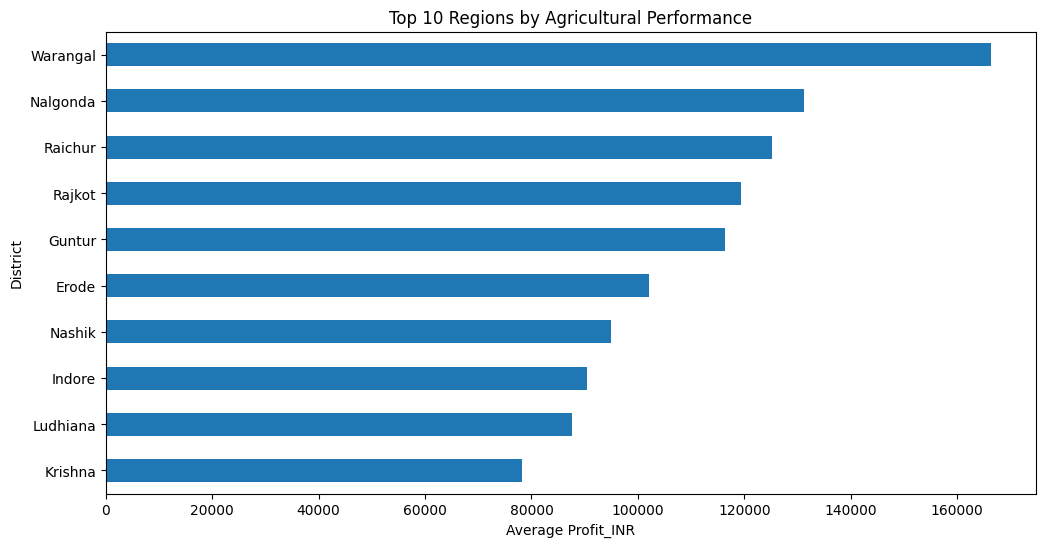

In [48]:
plt.figure(figsize=(12, 6))

region_summary.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Regions by Agricultural Performance")
plt.xlabel(f"Average {performance_col}")
plt.ylabel(region_col)

plt.show()

##31. Performance Ranking

In [49]:
df["Performance_Rank"] = (
    df[performance_col]
    .rank(
        ascending=False,
        method="dense"
    )
)

display(
    df.sort_values("Performance_Rank")
    .head(10)
)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Performance_Rank
2236,SF12237,Punjab,Rajkot,Chilli,Kharif,12.74,723.4,26.2,69.0,7.1,6.85,26.4,132.9,90.9,137.5,Flood,186.3,4.52,0.77,3.90,49.69,101780,712027,5057448,4345421,10398,4.779,52.3,1.0
626,SF10627,Maharashtra,Warangal,Chilli,Kharif,14.45,806.5,28.9,68.9,8.6,6.48,27.1,131.6,75.4,120.6,Flood,182.9,2.52,0.94,2.92,42.19,120429,1059050,5080900,4021850,10980,3.842,58.0,2.0
3425,SF13426,Madhya Pradesh,Rajkot,Sugarcane,Kharif,13.96,879.1,29.8,76.1,5.6,6.73,18.5,117.9,73.0,86.5,Drip,117.2,7.14,0.88,82.68,1154.21,3886,745161,4485260,3740099,23472,49.174,64.6,3.0
1690,SF11691,Karnataka,Warangal,Chilli,Kharif,13.04,921.0,28.4,77.6,6.5,6.65,39.2,141.1,46.1,96.0,Drip,163.1,4.65,0.97,3.01,39.25,115222,784135,4522464,3738329,7074,5.548,47.4,4.0
247,SF10248,Maharashtra,Krishna,Chilli,Kharif,14.86,566.3,27.6,69.4,6.4,6.41,30.1,166.0,28.7,104.4,Flood,199.3,7.14,0.69,3.09,45.92,105082,1283161,4825365,3542204,12869,3.568,40.2,5.0
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,14.74,589.1,24.2,54.5,8.0,6.81,19.1,151.3,80.3,127.8,Sprinkler,187.3,4.43,0.98,84.75,1249.21,3483,972119,4350998,3378879,23936,52.190,43.8,6.0
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,14.87,745.9,29.6,74.1,6.4,6.52,28.8,115.4,53.9,109.1,Drip,200.4,7.35,0.82,95.79,1424.40,3109,1097878,4428460,3330582,23289,61.162,42.7,7.0
1930,SF11931,Tamil Nadu,Guntur,Sugarcane,Kharif,14.16,860.4,26.5,74.0,5.0,7.14,29.7,157.2,66.1,151.7,Drip,122.0,5.71,0.73,79.25,1122.18,3661,875331,4108301,3232970,21133,53.101,41.8,8.0
3983,SF13984,Gujarat,Nashik,Chilli,Kharif,13.68,717.2,29.3,66.4,7.8,6.66,31.8,100.2,49.9,129.4,Drip,128.9,6.71,0.82,3.02,41.31,98175,844264,4055609,3211345,7219,5.722,49.6,9.0
263,SF10264,Maharashtra,Ludhiana,Chilli,Rabi,13.95,866.6,27.4,49.1,8.5,7.13,29.5,183.9,48.2,78.0,Sprinkler,182.4,3.33,0.85,2.53,35.29,112997,828217,3987664,3159447,8108,4.352,56.3,10.0


##32. Statistical Analysis

In [50]:
print("Skewness:")

for col in numeric_cols:
    print(
        f"{col}:",
        round(df[col].skew(), 3)
    )

Skewness:
Farm_Area_Hectares: -0.035
Rainfall_mm: 0.143
Avg_Temperature_C: 0.002
Humidity_pct: -0.024
Sunlight_Hours_Day: 0.073
Soil_pH: 0.052
Soil_Moisture_pct: -0.031
Nitrogen_kg_ha: 0.02
Phosphorus_kg_ha: 0.076
Potassium_kg_ha: -0.05
Fertilizer_kg_ha: 0.068
Pesticide_Litre_ha: 0.018
Seed_Quality_Score: -0.027
Yield_Tonnes_Ha: 4.058
Production_Tonnes: 5.129
Market_Price_INR_Tonne: 0.615
Total_Cost_INR: 0.167
Revenue_INR: 2.291
Profit_INR: 2.419
Water_Used_m3: 1.912
Water_Efficiency_t_per_1000m3: 4.279
Disease_Pest_Risk_pct: 0.048


### Statistical Distribution Analysis

Skewness was examined to understand whether agricultural variables
are symmetrically distributed or influenced by unusually high or low
observations.

Positive skewness indicates that the distribution has a longer right tail,
while negative skewness indicates a longer left tail.

##33. Relationship Between Two Important Variables

In [51]:
if len(numeric_cols) >= 2:

    x = numeric_cols[0]
    y = numeric_cols[1]

    correlation_value = df[x].corr(df[y])

    print(
        f"Correlation between {x} and {y}:",
        round(correlation_value, 3)
    )

Correlation between Farm_Area_Hectares and Rainfall_mm: 0.007


##34. Evidence-Based Recommendations

# Evidence-Based Recommendations

Based on the exploratory, seasonal, crop-level, regional, and correlation
analyses, the following recommendations can be considered:

1. **Focus on high-performing crop-season combinations**
   
   Agricultural planning should prioritize crop and season combinations
   that consistently demonstrate higher performance.

2. **Optimize seasonal planning**
   
   Farmers and agricultural planners can use historical seasonal patterns
   to determine suitable planting and harvesting periods.

3. **Improve resource allocation**
   
   Water, fertilizer, seeds, machinery, and other agricultural resources
   should be allocated according to crop and regional performance.

4. **Investigate low-performing regions**
   
   Regions with consistently low agricultural performance should be
   investigated for possible causes such as soil conditions, irrigation,
   climate, infrastructure, or farming practices.

5. **Use historical trends for planning**
   
   Yearly trends can support agricultural forecasting and long-term
   production planning.

6. **Monitor extreme observations**
   
   Very high or low agricultural values should be investigated to determine
   whether they represent genuine agricultural conditions or data-quality
   issues.

7. **Promote data-driven crop selection**
   
   Historical crop performance can support better crop-selection decisions
   for different seasons and regions.

8. **Consider multiple factors together**
   
   Agricultural performance should not be evaluated using a single variable.
   Crop, season, region, cultivated area, yield, and production should be
   considered together where available.

##35. 8 Meaningful Insights

# Key Insights

### Insight 1 – Best Performing Season

**Kharif** recorded the highest average profit of **₹178,914.65** per
farm, followed by **Rabi at ₹87,689.47**. In contrast, **Zaid recorded
an average loss of ₹24,804.82**. This indicates substantial variation
in profitability across agricultural seasons.

### Insight 2 – Seasonal Productivity

Kharif also recorded the highest average yield of **5.63 tonnes/ha**
and average production of **46.31 tonnes**. Rabi recorded an average
yield of **5.04 tonnes/ha**, while Zaid recorded the lowest average
yield of **4.64 tonnes/ha**. The higher productivity observed during
Kharif is consistent with its higher average profitability.

### Insight 3 – Best Performing Crop

**Sugarcane** was the most profitable crop, generating an average profit
of approximately **₹817,187.99** per farm. **Chilli** ranked second with
an average profit of approximately **₹750,878.34**. These crops generated
substantially higher average profits than the other crops in the dataset.

### Insight 4 – Crops With Negative Average Profit

Several crops recorded negative average profitability. **Wheat** had the
lowest average profit at approximately **-₹123,398.34**, followed by
**Rice at -₹102,213.50** and **Maize at -₹83,978.33**. This indicates that
these crops may require closer investigation of production costs, market
prices, yield, and revenue.

### Insight 5 – Strongest Correlation

The strongest correlation among the numerical variables was observed
between **Total Cost and Farm Area**, with a correlation coefficient of
**0.962**. This very strong positive relationship indicates that larger
farms generally require higher total expenditure.

### Insight 6 – High Variability in Agricultural Output

**Production_Tonnes** showed very high variability, with a coefficient
of variation of approximately **293.39%**. **Yield_Tonnes_Ha** also showed
high variability with a coefficient of variation of approximately
**253.92%**. This indicates substantial differences in agricultural
output across farms.

### Insight 7 – Crop Profitability Differences

The crop-level analysis shows a large difference in profitability.
Sugarcane and Chilli generated average profits above **₹750,000**, while
Wheat, Rice, and Maize recorded negative average profits. This suggests
that crop selection can have a major influence on farm profitability.

### Insight 8 – Profit Outliers

The IQR-based outlier analysis identified **404 outliers in Profit_INR**,
representing **10.10% of the dataset**. Profit ranged from approximately
**-₹1,019,223 to ₹4,345,421**. These extreme observations may represent
exceptionally profitable or loss-making farms and should be investigated
rather than automatically removed.

##36. Limitations

# Limitations

1. The analysis is based only on the variables available in the dataset.

2. Historical agricultural data may not capture all environmental factors
   such as rainfall, temperature, soil quality, pests, diseases, and
   irrigation availability.

3. Correlation between variables does not necessarily imply causation.

4. Extreme observations may represent genuine agricultural conditions and
   therefore were not automatically removed.

5. The dataset may contain regional or temporal biases.

6. Missing values and data-quality issues may affect some results.

7. External economic factors such as market prices, input costs, government
   policies, and subsidies may not be represented.

8. The findings should therefore be interpreted as analytical evidence
   rather than definitive causal conclusions.

##37. Final Conclusion

# Conclusion

This project analyzed agricultural performance using exploratory data
analysis, statistical analysis, visualization, correlation analysis,
seasonal comparisons, and crop-level analysis.

The analysis demonstrated that agricultural performance can vary across
seasons, crops, regions, and other agricultural factors. Seasonal analysis
helps identify favorable periods, while crop and regional analysis helps
identify areas of relatively strong or weak performance.

The correlation and multivariate analyses provided additional understanding
of relationships among agricultural variables. Outlier analysis helped
identify unusual observations that may require further investigation.

Overall, the project demonstrates how data analytics can support
data-driven agricultural planning, resource allocation, crop selection,
and performance monitoring.

Future analysis could incorporate weather conditions, soil characteristics,
rainfall, irrigation, fertilizer usage, market prices, and other external
factors to develop more comprehensive agricultural prediction and
decision-support models.

# Submission Checklist

☑ Dataset loaded successfully

☑ Top 5 rows analyzed

☑ Dataset shape and structure examined

☑ Data types examined

☑ Missing values identified and handled

☑ Duplicate records identified and handled

☑ Descriptive/statistical analysis performed

☑ Outliers investigated

☑ Univariate analysis completed

☑ Bivariate analysis completed

☑ Multivariate analysis completed

☑ Correlation analysis completed

☑ Seasonal comparisons performed

☑ At least 3 student-designed analyses completed

☑ At least 8 meaningful insights documented

☑ Evidence-based recommendations provided

☑ Limitations discussed

☑ Final conclusion provided